In [1]:
import numpy as np
import pandas as pd
import os 
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import sem
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error

# Set up plotting style
plt.rcParams.update({'font.size': 12})
sns.set_style("whitegrid")


In [2]:
# Configuration for paw speed
base_path = "/media/lenny-aharon/T7/ibl-mouse/ibl-mouse_neural-activity/results"


eids = [
    "15b69921-d471-4ded-8814-2adad954bcd8",    
    "15763234-d21e-491f-a01b-1238eb96d389", 
    "aad23144-0e52-4eac-80c5-c4ee2decb198",
    "9b528ad0-4599-4a55-9148-96cc1d93fb24",
    "4b00df29-3769-43be-bb40-128b1cba6d35",
    "0841d188-8ef2-4f20-9828-76a94d5343a4", # resnet is doing better than MVT
    "f312aaec-3b6f-44b3-86b4-3a0c119c0438",
    "0f77ca5d-73c2-45bd-aa4c-4c5ed275dbde",
    "1b715600-0cbc-442c-bd00-5b0ac2865de1",
    
    "3bcb81b4-d9ca-4fc9-a1cd-353a966239ca",
    # "03d9a098-07bf-4765-88b7-85f8d8f620cc", # very bad with EKS 
    "3e6a97d3-3991-49e2-b346-6948cb4580fb",
    "3f859b5c-e73a-4044-b49e-34bb81e96715", # bad with EKS 
    "4b7fbad4-f6de-43b4-9b15-c7c7ef44db4b",
    "5ae68c54-2897-4d3a-8120-426150704385",
    "5dcee0eb-b34d-4652-acc3-d10afc6eae68",
    # "6c6b0d06-6039-4525-a74b-58cfaa1d3a60", # I used to comment out 
    "7cb81727-2097-4b52-b480-c89867b5b34c",
    "8a3a0197-b40a-449f-be55-c00b23253bbf",
    "30c4e2ab-dffc-499d-aae4-e51d6b3218c2",
    "51e53aff-1d5d-4182-a684-aba783d50ae5",
    # "61e11a11-ab65-48fb-ae08-3cb80662e5d6", # bad with EKS 
    "746d1902-fa59-4cab-b0aa-013be36060d5",
    "824cf03d-4012-4ab1-b499-c83a92c5589e",

    "3638d102-e8b6-4230-8742-e548cd87a949",
    "6899a67d-2e53-4215-a52a-c7021b5da5d4",
    "8928f98a-b411-497e-aa4b-aa752434686d",

    # This 2 sessions need to be removed
    # "71e55bfe-5a3a-4cba-bdc7-f085140d798e",
    # "754b74d5-7a06-4004-ae0c-72a10b6ed2e6",
    # "5c0c560e-9e1f-45e9-b66e-e4ee7855be84",
]

# eid = "0841d188-8ef2-4f20-9828-76a94d5343a4"
eid = "15763234-d21e-491f-a01b-1238eb96d389" # this is a good session
# eid = "7cb81727-2097-4b52-b480-c89867b5b34c"

# target = "lightning-pose-left-pawL-speed"  # The paw speed target we decoded
# target = "lightning-pose-right-pawL-speed"  # The paw speed target we decoded
# target = "lightning-pose-left-pawR-speed"  # The paw speed target we decoded
# target = "lightning-pose-right-pawR-speed"  # The paw speed target we decoded
target = "lightning-pose-pawL-3d-speed"  # The paw speed target we decoded
# target = "lightning-pose-pawR-3d-speed" 

model = "linear"
# model = "reduced_rank"

# Define the two pose models to compare
# pose_models = ["resnet50_median", "MVT_3d_aug_patch_median", "MVT_3d_aug_patch_eks_linear"]
# pose_models = ["resnet50_median", "MVT_3d_aug_patch_median", "MVT_3d_aug_patch_eks_linear", "resnet50_eks_linear"]
# pose_models = ["resnet50_median", "MVT_3d_aug_patch_median", "MVT_3d_aug_patch_median_400"]
# pose_models = ["resnet50_median_new", "MVT_3d_aug_patch_median_new", "MVT_3d_aug_patch_eks_linear_new"]
pose_models = ["resnet50_median_new", "MVT_3d_aug_patch_median_new"]
# pose_models = ["resnet50_median", "MVT_3d_aug_patch_median"]
# pose_models = ["resnet50_median"]



In [3]:
import os
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

def load_session_results(base_path, eid, target, pose_models, model_method="linear"):
    """
    Loads cross-validation results for multiple pose models.
    Automatically detects and flattens all coordinate and variance data,
    including 3D triangulation and multi-view keys.
    """
    results = {}
    
    for pose_model in pose_models:
        results_path = f"{base_path}/{eid}/{target}/{pose_model}/{model_method}/all/{eid}_cv.npy"
        
        if not os.path.exists(results_path):
            print(f"Warning: Results not found at {results_path}")
            continue
            
        print(f"\n{'='*40}")
        print(f"Loading: {pose_model}")
        
        # Load the data dictionary
        data = np.load(results_path, allow_pickle=True).item()
        
        # 1. Core Speed Data
        test_y = data['all_test_y']
        test_pred = data['all_test_pred']
        y_flat = test_y.flatten()
        pred_flat = test_pred.flatten()
                
        # 2. Initialize result container for this model
        res = {
            'test_y': test_y,
            'test_pred': test_pred,
            'y_flattened': y_flat,
            'pred_flattened': pred_flat,
            'test_metric': data['overall_metric'],
            'r2': r2_score(y_flat, pred_flat),
            'mse': mean_squared_error(y_flat, pred_flat),
            'correlation': np.corrcoef(y_flat, pred_flat)[0, 1],
            # Mapping Info
            'test_frame_indices': data.get('all_test_frame_indices'),
            'test_original_trial_ids': data.get('all_test_original_trial_indices')
        }
        
        # 3. Dynamic Ensemble/Coordinate extraction
        # This will automatically pick up: x_ens_var, left_x_ens_var, x_3d, etc.
        ens_data = data.get('all_test_ens_vars', {})
        for key, val in ens_data.items():
            if val is not None:
                res[key] = val
                res[f"{key}_flattened"] = val.flatten()
        
        # Load all available ensemble/coordinate data
        ens_data = data.get('all_test_ens_vars', {})
        for key, val in ens_data.items():
            if val is not None:
                res[key] = val
                res[f"{key}_flattened"] = val.flatten()
        
        # --- CALCULATE UNIFIED AVERAGE VARIANCE ---
        # CASE A: 2D Target (has x_ens_var and y_ens_var)
        if 'x_ens_var' in res and 'y_ens_var' in res:
            avg_var = (res['x_ens_var'] + res['y_ens_var']) / 2
            res['avg_ens_var_flattened'] = avg_var.flatten()
            
        # CASE B: 3D Target (has left_x_ens_var, right_x_ens_var, etc.)
        elif 'left_x_ens_var' in res and 'right_x_ens_var' in res:
            # Average across all 4 components (Left X, Left Y, Right X, Right Y)
            all_vars = [res['left_x_ens_var'], res['left_y_ens_var'], 
                        res['right_x_ens_var'], res['right_y_ens_var']]
            avg_var = sum(all_vars) / 4
            res['avg_ens_var_flattened'] = avg_var.flatten()

        results[pose_model] = res
        
        # Print summary
        print(f"  Target: {target}")
        print(f"  Session: {eid}")
        print(f"  Trials: {len(res['test_original_trial_ids']) if res['test_original_trial_ids'] is not None else 'Unknown'}")
        print(f"  R² (flattened): {res['r2']:.3f}")
        
        # List what was extracted (for debugging)
        extracted_keys = [k for k in ens_data.keys() if ens_data[k] is not None]
        if extracted_keys:
            print(f"  Extracted vars: {', '.join(extracted_keys)}")

    return results

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Collect data into a list of records
records = []
for eid1 in eids:
    results = load_session_results(base_path, eid1, target, pose_models, model_method=model)
    for pose_model in pose_models:
        if pose_model in results:
            records.append({
                'Session': eid1,
                'Model': pose_model,
                'R2': results[pose_model]['r2']
            })

df_results = pd.DataFrame(records)


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15763234-d21e-491f-a01b-1238eb96d389
  Trials: 349
  R² (flattened): 0.158
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new


In [5]:
r2_values_sessions = []
for eid1 in eids:
    results = load_session_results(base_path, eid1, target, pose_models,model_method=model)
    
    # Extract R² values for each pose model in this session
    for pose_model in pose_models:
        if pose_model in results:
            r2_values_sessions.append(results[pose_model]['r2'])

# Calculate average R² across all sessions for each pose model
r2_by_model = {}
for eid1 in eids:
    results = load_session_results(base_path, eid1, target, pose_models, model_method=model)
    
    # Extract R² values for each pose model in this session
    for pose_model in pose_models:
        if pose_model in results:
            if pose_model not in r2_by_model:
                r2_by_model[pose_model] = []
            r2_by_model[pose_model].append(results[pose_model]['r2'])

# Print average R² for each pose model
print(f"\nAverage R² across all sessions by pose model:")
print(f" the target is {target}")
for pose_model in pose_models:
    if pose_model in r2_by_model and r2_by_model[pose_model]:
        avg_r2 = np.mean(r2_by_model[pose_model])
        std_r2 = np.std(r2_by_model[pose_model])
        print(f"  {pose_model}: {avg_r2:.3f} ± {std_r2:.3f} (n={len(r2_by_model[pose_model])})")
    else:
        print(f"  {pose_model}: No data found")



Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15763234-d21e-491f-a01b-1238eb96d389
  Trials: 349
  R² (flattened): 0.158
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new


In [6]:
# Print average R² for each pose model
print(f"\nAverage R² across all sessions by pose model:")
print(f" the target is {target}")
for pose_model in pose_models:
    if pose_model in r2_by_model and r2_by_model[pose_model]:
        avg_r2 = np.mean(r2_by_model[pose_model])
        std_r2 = np.std(r2_by_model[pose_model])
        print(f"  {pose_model}: {avg_r2:.3f} ± {std_r2:.3f} (n={len(r2_by_model[pose_model])})")
    else:
        print(f"  {pose_model}: No data found")




Average R² across all sessions by pose model:
 the target is lightning-pose-pawL-3d-speed
  resnet50_median_new: 0.160 ± 0.062 (n=24)
  MVT_3d_aug_patch_median_new: 0.178 ± 0.067 (n=24)


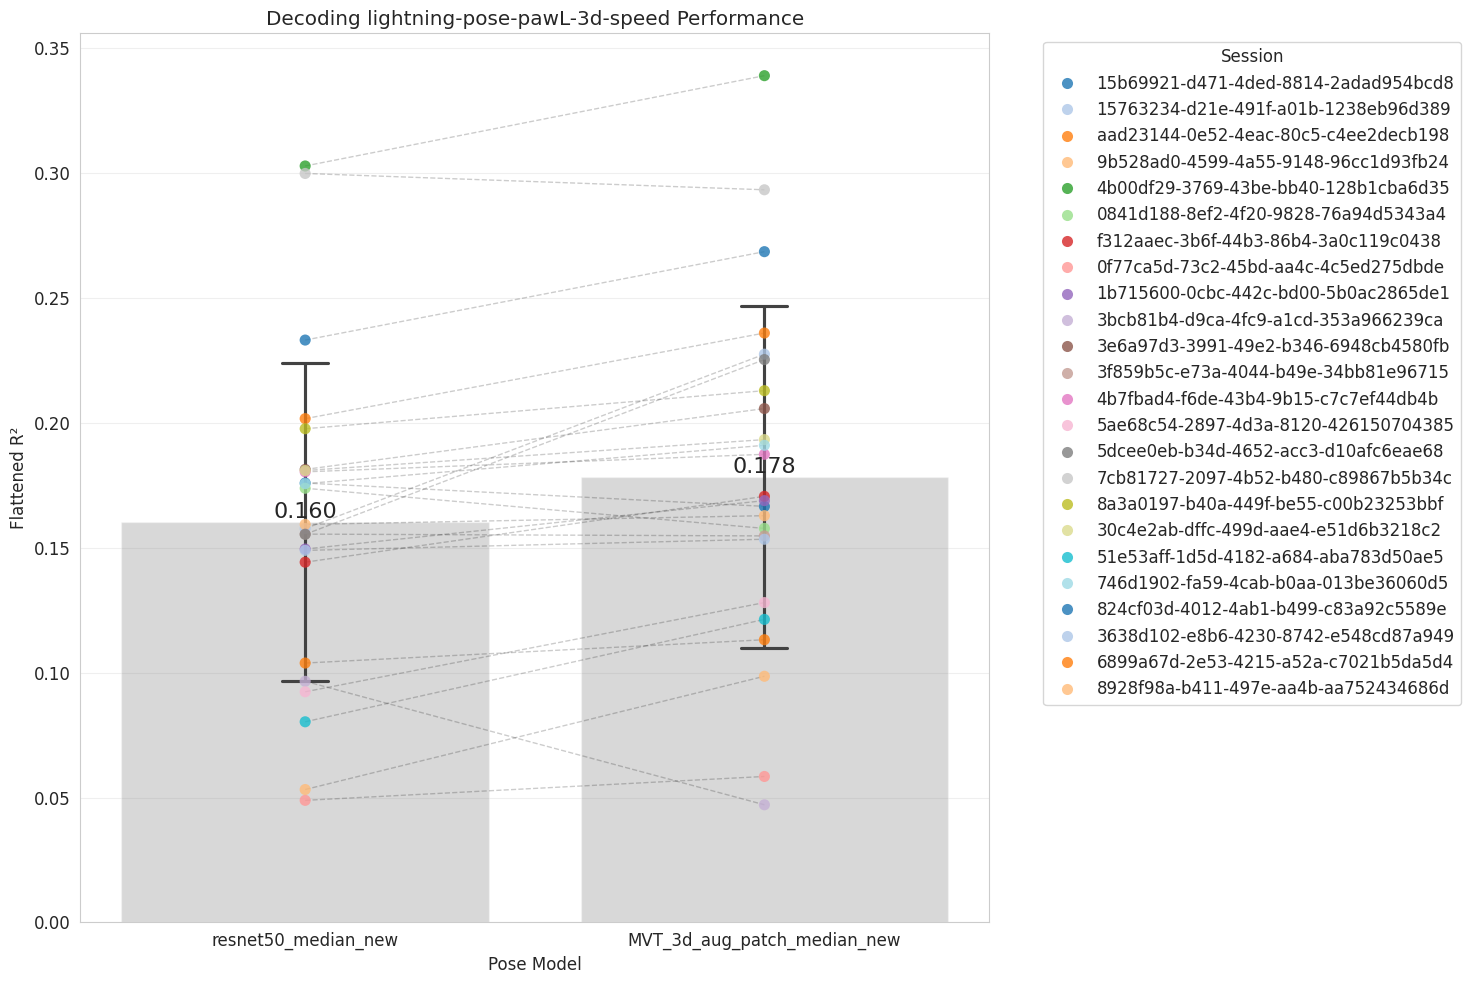

In [7]:
def plot_session_comparison(df, title="Model Performance Across Sessions"):
    plt.figure(figsize=(15, 10))
    
    # 1. Draw the Bars (Mean performance)
    # Change estimator=np.median if you prefer median over mean
    sns.barplot(data=df, x='Model', y='R2', alpha=0.3, color='gray', capsize=.1, errorbar='sd')
    
    # 2. Draw the Individual Session Points
    # palette='viridis' or any other color scheme you like
    sns.stripplot(data=df, x='Model', y='R2', hue='Session', size=8, jitter=False, palette='tab20', alpha=0.8)

    # add the averaged R^2 value for each model below its graph for up to 3 decimal values
    for model in df['Model'].unique():
        model_data = df[df['Model'] == model]
        avg_r2 = model_data['R2'].mean()
        plt.text(model, avg_r2, f'{avg_r2:.3f}', ha='center', va='bottom', fontsize=16)
    
    # 3. Draw Connecting Lines
    # We pivot to get a matrix where rows=sessions, cols=models
    pivot_df = df.pivot(index='Session', columns='Model', values='R2')
    # Get the x-positions of the bars for plotting lines correctly
    model_order = [m for m in df['Model'].unique() if m in pivot_df.columns]
    x_coords = range(len(model_order))
    
    for session_id, row in pivot_df.iterrows():
        # Plot a line for each session across the models
        y_values = [row[m] for m in model_order]
        plt.plot(x_coords, y_values, color='black', alpha=0.2, linestyle='--', linewidth=1, zorder=1)

    plt.title(title)
    plt.ylabel("Flattened R²")
    plt.xlabel("Pose Model")
    plt.ylim(bottom=0) # Often R2 is best viewed from 0 up
    plt.grid(axis='y', alpha=0.3)
    plt.legend(title="Session", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_session_comparison(df_results, title=f"Decoding {target} Performance")

In [8]:
# Define colors for each pose model
# Darker color for pose model (ground truth), lighter for decoded prediction
colors = {
    # 'MVT_patch_masking_median': {
    #     'pose': '#1f77b4',      # Dark blue
    #     'decoded': '#aec7e8'    # Light blue
    # },
    'MVT_3d_aug_patch_median': {
        'pose': '#1f77b4',      # Dark blue
        'decoded': '#aec7e8'    # Light blue
    },
    'resnet50_median': {
        'pose': '#d62728',      # Dark red
        'decoded': '#ff9896'    # Light red/pink
    },

    'MVT_3d_aug_patch_median_new': {
        'pose': '#1f77b4',      # Dark blue
        'decoded': '#aec7e8'    # Light blue
    },
    'resnet50_median_new': {
        'pose': '#d62728',      # Dark red
        'decoded': '#ff9896'    # Light red/pink
    },

    'MVT_3d_aug_patch_eks_linear_new': {
        'pose': 'green',      
        'decoded': 'lightgreen'    
    },

    # 'MVT_3d_aug_patch_eks': {
    #     'pose': 'green',      
    #     'decoded': 'lightgreen'    
    # },
    'MVT_3d_aug_patch_median_400': {
        'pose': 'purple',      # Dark blue
        'decoded': 'lightpurple'    # Light blue
    },

    'MVT_3d_aug_patch_eks_linear': {
        'pose': 'green',      
        'decoded': 'lightgreen'    
    },

    'MVT_3d_aug_patch_0': {
        'pose': '#1f77b4',      # Dark blue
        'decoded': '#aec7e8'    # Light blue
    },
    'resnet50_0': {
        'pose': '#d62728',      # Dark red
        'decoded': '#ff9896'    # Light red/pink
    }
}


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15763234-d21e-491f-a01b-1238eb96d389
  Trials: 349
  R² (flattened): 0.158
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new


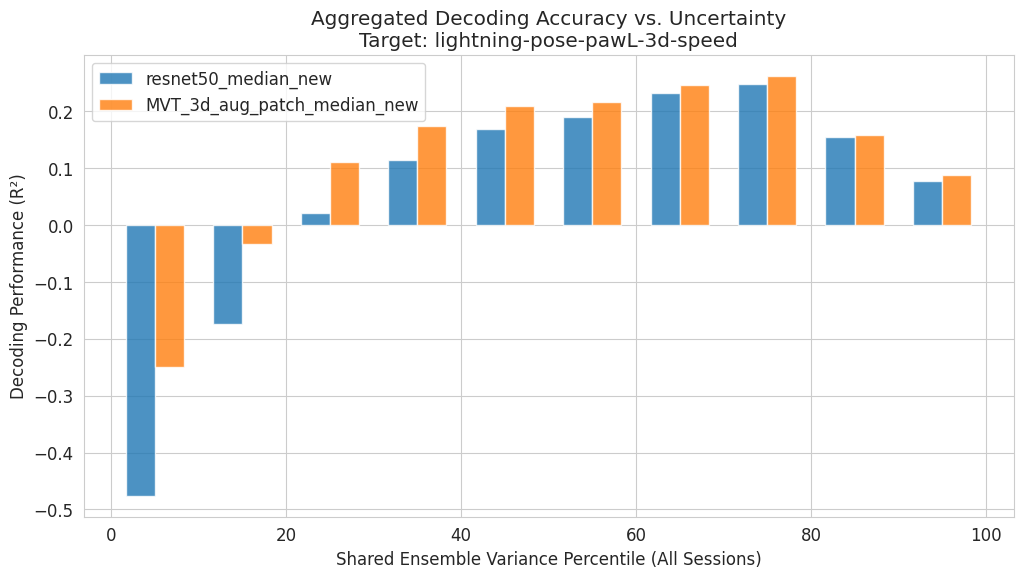

In [9]:
def plot_performance_by_shared_variance_all_sessions(base_path, eids, target, pose_models, n_bins=10):
    """
    Aggregates all sessions and plots R2 vs shared variance percentiles.
    """
    agg_data = {m: {'y': [], 'pred': [], 'var': []} for m in pose_models}

    for eid in eids:
        res_dict = load_session_results(base_path, eid, target, pose_models)
        for m in pose_models:
            if m in res_dict and 'avg_ens_var_flattened' in res_dict[m]:
                agg_data[m]['y'].append(res_dict[m]['y_flattened'])
                agg_data[m]['pred'].append(res_dict[m]['pred_flattened'])
                agg_data[m]['var'].append(res_dict[m]['avg_ens_var_flattened'])

    # Concatenate
    shared_vars = []
    for m in pose_models:
        agg_data[m]['y'] = np.concatenate(agg_data[m]['y'])
        agg_data[m]['pred'] = np.concatenate(agg_data[m]['pred'])
        agg_data[m]['var'] = np.concatenate(agg_data[m]['var'])
        shared_vars.append(agg_data[m]['var'])

    shared_var_scale = np.mean(shared_vars, axis=0)
    percentiles = np.linspace(0, 100, n_bins + 1)
    thresholds = np.percentile(shared_var_scale, percentiles)
    bin_centers = (percentiles[:-1] + percentiles[1:]) / 2

    plt.figure(figsize=(12, 6))
    width = 10 / (len(pose_models) + 1)
    
    for i, m in enumerate(pose_models):
        bin_r2s = []
        for j in range(n_bins):
            mask = (shared_var_scale >= thresholds[j]) & (shared_var_scale < thresholds[j+1])
            bin_r2s.append(r2_score(agg_data[m]['y'][mask], agg_data[m]['pred'][mask]))
        
        offset = (i - len(pose_models)/2 + 0.5) * width
        plt.bar(bin_centers + offset, bin_r2s, width=width, label=m, alpha=0.8)

    plt.xlabel('Shared Ensemble Variance Percentile (All Sessions)')
    plt.ylabel('Decoding Performance (R²)')
    plt.title(f'Aggregated Decoding Accuracy vs. Uncertainty\nTarget: {target}')
    plt.legend()
    plt.show()

plot_performance_by_shared_variance_all_sessions(base_path, eids, target, pose_models)


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15763234-d21e-491f-a01b-1238eb96d389
  Trials: 349
  R² (flattened): 0.158
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new


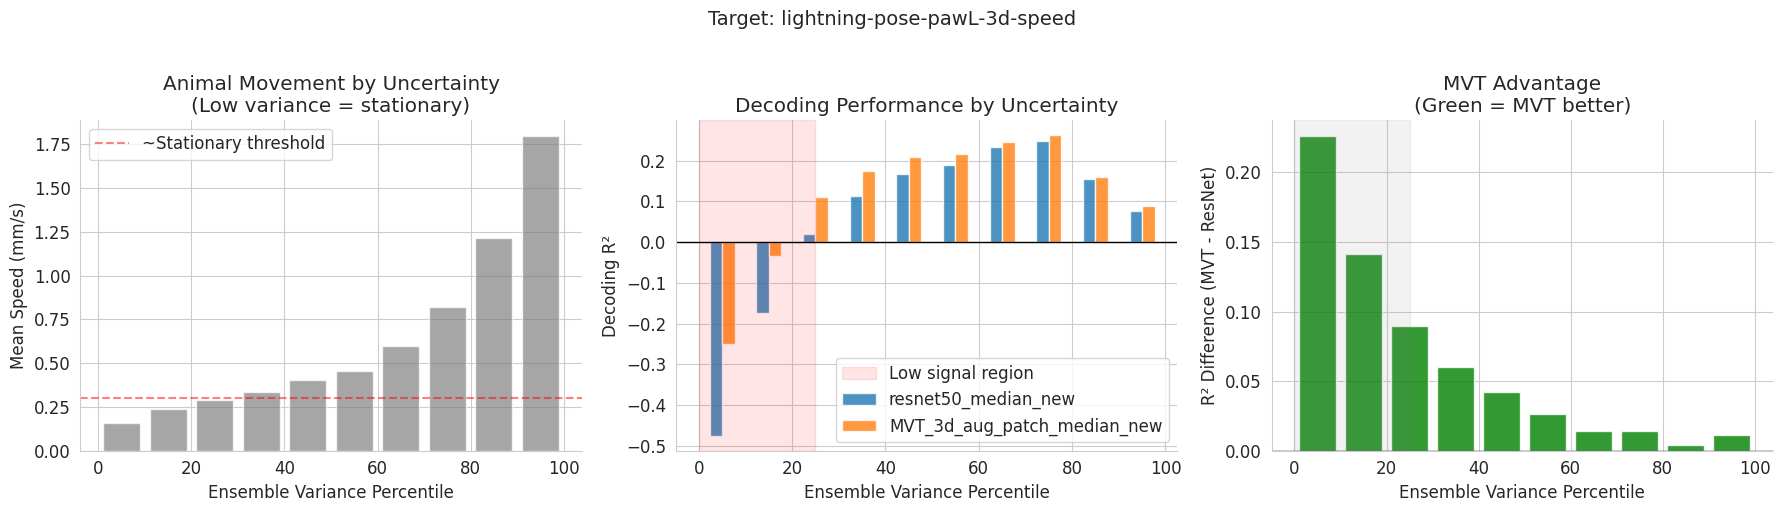


=== Summary (Meaningful Range: 30-80%) ===
resnet50_median_new: Mean R² = 0.1908
MVT_3d_aug_patch_median_new: Mean R² = 0.2222
MVT advantage: 0.0314


In [11]:
def plot_performance_by_variance_with_context(base_path, eids, target, pose_models, n_bins=10):
    """
    Plot R² vs variance with context about what each bin represents.
    """
    agg_data = {m: {'y': [], 'pred': [], 'var': []} for m in pose_models}
    
    for eid in eids:
        res_dict = load_session_results(base_path, eid, target, pose_models)
        for m in pose_models:
            if m in res_dict and 'avg_ens_var_flattened' in res_dict[m]:
                agg_data[m]['y'].append(res_dict[m]['y_flattened'])
                agg_data[m]['pred'].append(res_dict[m]['pred_flattened'])
                agg_data[m]['var'].append(res_dict[m]['avg_ens_var_flattened'])
    
    for m in pose_models:
        agg_data[m]['y'] = np.concatenate(agg_data[m]['y'])
        agg_data[m]['pred'] = np.concatenate(agg_data[m]['pred'])
        agg_data[m]['var'] = np.concatenate(agg_data[m]['var'])
    
    shared_vars = [agg_data[m]['var'] for m in pose_models]
    shared_var_scale = np.mean(shared_vars, axis=0)
    
    percentiles = np.linspace(0, 100, n_bins + 1)
    thresholds = np.percentile(shared_var_scale, percentiles)
    thresholds[-1] += 1e-9
    bin_centers = (percentiles[:-1] + percentiles[1:]) / 2
    
    # Compute R² and mean speed for each bin
    results = {m: [] for m in pose_models}
    mean_speeds = []
    
    for j in range(n_bins):
        mask = (shared_var_scale >= thresholds[j]) & (shared_var_scale < thresholds[j+1])
        mean_speeds.append(np.mean(agg_data[pose_models[0]]['y'][mask]))
        
        for m in pose_models:
            if mask.sum() < 2:
                results[m].append(np.nan)
            else:
                results[m].append(r2_score(agg_data[m]['y'][mask], agg_data[m]['pred'][mask]))
    
    for m in pose_models:
        results[m] = np.array(results[m])
    
    # === PLOT ===
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: Mean speed by bin (context)
    ax = axes[0]
    ax.bar(bin_centers, mean_speeds, width=8, color='gray', alpha=0.7)
    ax.set_xlabel('Ensemble Variance Percentile')
    ax.set_ylabel('Mean Speed (mm/s)')
    ax.set_title('Animal Movement by Uncertainty\n(Low variance = stationary)')
    ax.axhline(0.3, color='red', linestyle='--', alpha=0.5, label='~Stationary threshold')
    ax.legend()
    sns.despine(ax=ax)
    
    # Plot 2: R² comparison
    ax = axes[1]
    width = 8 / (len(pose_models) + 1)
    for i, m in enumerate(pose_models):
        offset = (i - len(pose_models)/2 + 0.5) * width
        ax.bar(bin_centers + offset, results[m], width=width, label=m, alpha=0.8)
    ax.axhline(0, color='black', linestyle='-', lw=1)
    ax.axvspan(0, 25, alpha=0.1, color='red', label='Low signal region')
    ax.set_xlabel('Ensemble Variance Percentile')
    ax.set_ylabel('Decoding R²')
    ax.set_title('Decoding Performance by Uncertainty')
    ax.legend()
    sns.despine(ax=ax)
    
    # Plot 3: MVT advantage
    ax = axes[2]
    diff = results[pose_models[1]] - results[pose_models[0]]
    colors = ['green' if d > 0 else 'red' for d in diff]
    ax.bar(bin_centers, diff, width=8, color=colors, alpha=0.8)
    ax.axhline(0, color='black', linestyle='-', lw=1)
    ax.axvspan(0, 25, alpha=0.1, color='gray', label='Low signal (ignore)')
    ax.set_xlabel('Ensemble Variance Percentile')
    ax.set_ylabel('R² Difference (MVT - ResNet)')
    ax.set_title('MVT Advantage\n(Green = MVT better)')
    sns.despine(ax=ax)
    
    plt.suptitle(f'Target: {target}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Summary for meaningful range only (30-80%)
    print("\n=== Summary (Meaningful Range: 30-80%) ===")
    meaningful_idx = [3, 4, 5, 6, 7]  # bins 30-80%
    for m in pose_models:
        print(f"{m}: Mean R² = {np.mean([results[m][i] for i in meaningful_idx]):.4f}")
    print(f"MVT advantage: {np.mean([diff[i] for i in meaningful_idx]):.4f}")


plot_performance_by_variance_with_context(base_path, eids, target, pose_models)


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15763234-d21e-491f-a01b-1238eb96d389
  Trials: 349
  R² (flattened): 0.158
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new


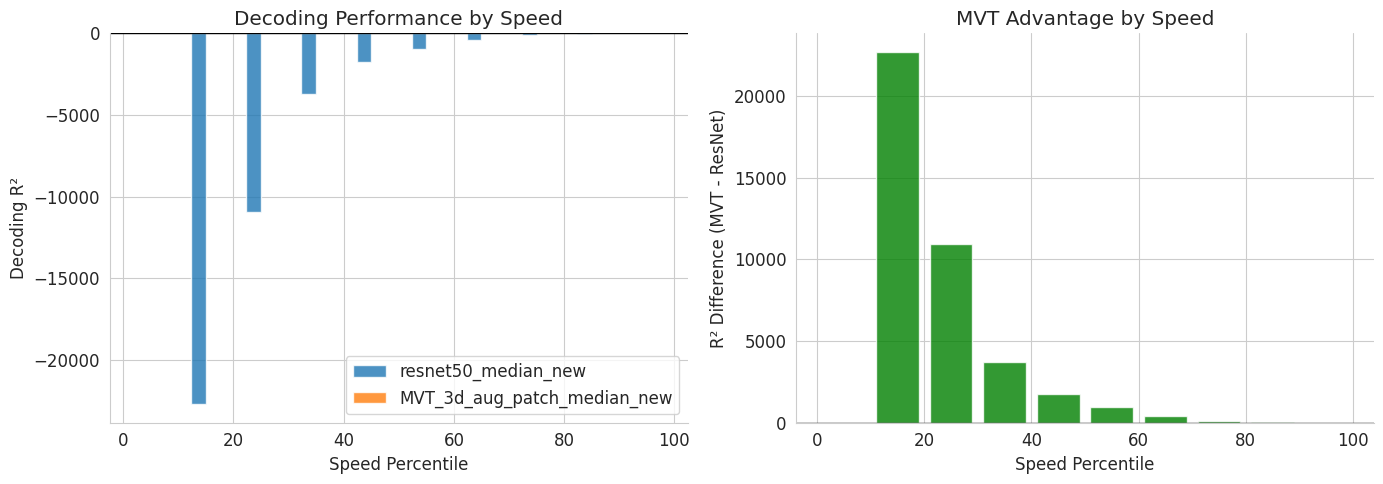

In [12]:
def plot_performance_by_speed(base_path, eids, target, pose_models, n_bins=10):
    """
    Plot decoding R² binned by actual speed (not variance).
    """
    agg_data = {m: {'y': [], 'pred': [], 'var': []} for m in pose_models}
    
    for eid in eids:
        res_dict = load_session_results(base_path, eid, target, pose_models)
        for m in pose_models:
            if m in res_dict and 'avg_ens_var_flattened' in res_dict[m]:
                agg_data[m]['y'].append(res_dict[m]['y_flattened'])
                agg_data[m]['pred'].append(res_dict[m]['pred_flattened'])
                agg_data[m]['var'].append(res_dict[m]['avg_ens_var_flattened'])
    
    for m in pose_models:
        agg_data[m]['y'] = np.concatenate(agg_data[m]['y'])
        agg_data[m]['pred'] = np.concatenate(agg_data[m]['pred'])
        agg_data[m]['var'] = np.concatenate(agg_data[m]['var'])
    
    # Bin by SPEED (y) instead of variance
    y_all = agg_data[pose_models[0]]['y']
    percentiles = np.linspace(0, 100, n_bins + 1)
    thresholds = np.percentile(y_all, percentiles)
    thresholds[-1] += 1e-9
    bin_centers = (percentiles[:-1] + percentiles[1:]) / 2
    
    results = {m: [] for m in pose_models}
    mean_speeds = []
    mean_vars = []
    
    for j in range(n_bins):
        mask = (y_all >= thresholds[j]) & (y_all < thresholds[j+1])
        mean_speeds.append(np.mean(y_all[mask]))
        mean_vars.append(np.mean(agg_data[pose_models[0]]['var'][mask]))
        
        for m in pose_models:
            if mask.sum() < 2:
                results[m].append(np.nan)
            else:
                results[m].append(r2_score(agg_data[m]['y'][mask], agg_data[m]['pred'][mask]))
    
    for m in pose_models:
        results[m] = np.array(results[m])
    
    diff = results[pose_models[1]] - results[pose_models[0]]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # R² by speed
    ax = axes[0]
    width = 8 / (len(pose_models) + 1)
    for i, m in enumerate(pose_models):
        offset = (i - len(pose_models)/2 + 0.5) * width
        ax.bar(bin_centers + offset, results[m], width=width, label=m, alpha=0.8)
    ax.axhline(0, color='black', linestyle='-', lw=1)
    ax.set_xlabel('Speed Percentile')
    ax.set_ylabel('Decoding R²')
    ax.set_title('Decoding Performance by Speed')
    ax.legend()
    sns.despine(ax=ax)
    
    # MVT advantage by speed
    ax = axes[1]
    colors = ['green' if d > 0 else 'red' for d in diff]
    ax.bar(bin_centers, diff, width=8, color=colors, alpha=0.8)
    ax.axhline(0, color='black', linestyle='-', lw=1)
    ax.set_xlabel('Speed Percentile')
    ax.set_ylabel('R² Difference (MVT - ResNet)')
    ax.set_title('MVT Advantage by Speed')
    sns.despine(ax=ax)
    
    plt.tight_layout()
    plt.show()


plot_performance_by_speed(base_path, eids, target, pose_models)


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15763234-d21e-491f-a01b-1238eb96d389
  Trials: 349
  R² (flattened): 0.158
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new


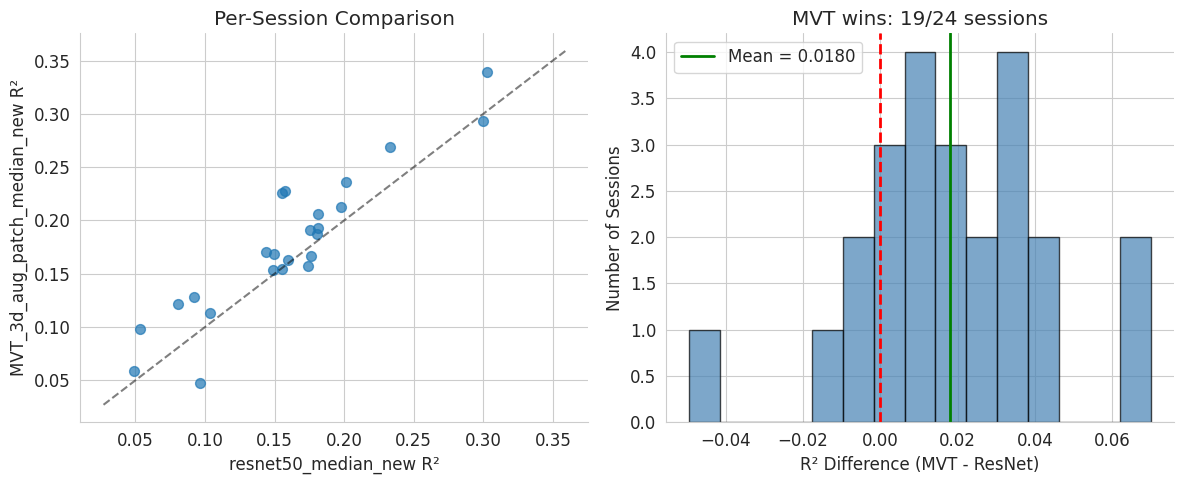


Paired t-test: t = 3.337, p = 0.0029


In [14]:
def plot_paired_session_comparison(base_path, eids, target, pose_models):
    """
    Paired comparison showing which model wins per session.
    """
    session_results = []
    
    for eid in eids:
        res_dict = load_session_results(base_path, eid, target, pose_models)
        
        row = {'eid': eid}
        for m in pose_models:
            if m in res_dict:
                y = res_dict[m]['y_flattened']
                pred = res_dict[m]['pred_flattened']
                row[m] = r2_score(y, pred)
        
        if len(row) == len(pose_models) + 1:
            session_results.append(row)
    
    df = pd.DataFrame(session_results)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Scatter: model vs model
    ax = axes[0]
    ax.scatter(df[pose_models[0]], df[pose_models[1]], alpha=0.7, s=50)
    lims = [min(df[pose_models[0]].min(), df[pose_models[1]].min()) - 0.02,
            max(df[pose_models[0]].max(), df[pose_models[1]].max()) + 0.02]
    ax.plot(lims, lims, 'k--', alpha=0.5)
    ax.set_xlabel(f'{pose_models[0]} R²')
    ax.set_ylabel(f'{pose_models[1]} R²')
    ax.set_title('Per-Session Comparison')
    sns.despine(ax=ax)
    
    # Count wins
    df['diff'] = df[pose_models[1]] - df[pose_models[0]]
    mvt_wins = (df['diff'] > 0).sum()
    resnet_wins = (df['diff'] < 0).sum()
    
    # Histogram of differences
    ax = axes[1]
    ax.hist(df['diff'], bins=15, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', lw=2)
    ax.axvline(df['diff'].mean(), color='green', linestyle='-', lw=2, label=f'Mean = {df["diff"].mean():.4f}')
    ax.set_xlabel('R² Difference (MVT - ResNet)')
    ax.set_ylabel('Number of Sessions')
    ax.set_title(f'MVT wins: {mvt_wins}/{len(df)} sessions')
    ax.legend()
    sns.despine(ax=ax)
    
    plt.tight_layout()
    plt.show()
    
    # Stats
    from scipy import stats
    t_stat, p_val = stats.ttest_rel(df[pose_models[1]], df[pose_models[0]])
    print(f"\nPaired t-test: t = {t_stat:.3f}, p = {p_val:.4f}")


plot_paired_session_comparison(base_path, eids, target, pose_models)


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15763234-d21e-491f-a01b-1238eb96d389
  Trials: 349
  R² (flattened): 0.158
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new


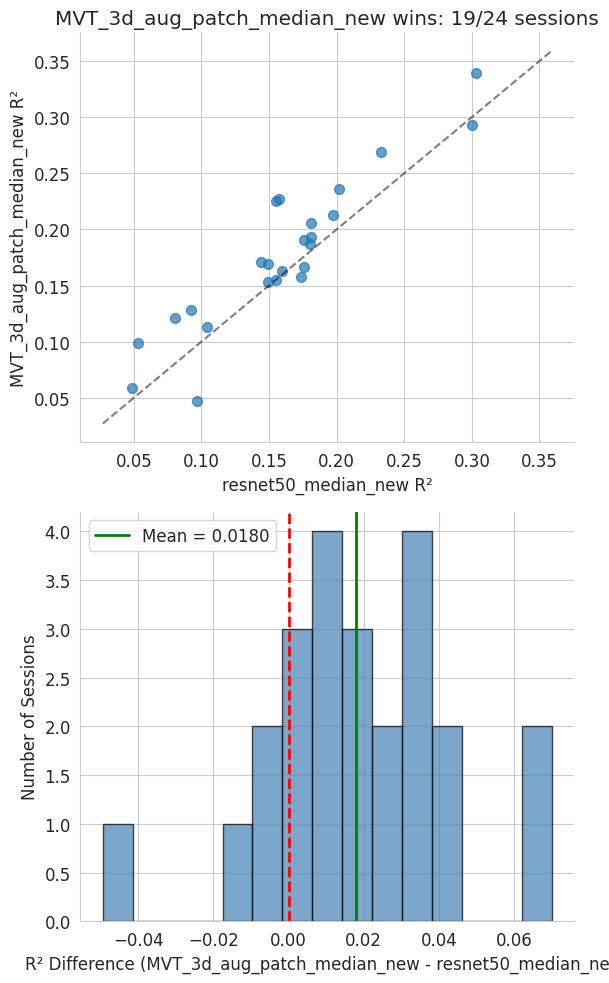

In [16]:
def plot_paired_session_comparison(base_path, eids, target, pose_models):
    """
    Paired comparison for multiple models showing which model wins per session.
    """
    session_results = []
    
    for eid in eids:
        res_dict = load_session_results(base_path, eid, target, pose_models)
        
        row = {'eid': eid}
        for m in pose_models:
            if m in res_dict:
                y = res_dict[m]['y_flattened']
                pred = res_dict[m]['pred_flattened']
                row[m] = r2_score(y, pred)
        
        if len(row) == len(pose_models) + 1:  # All models present
            session_results.append(row)
    
    df = pd.DataFrame(session_results)
    
    n_models = len(pose_models)
    n_pairs = n_models * (n_models - 1) // 2  # Number of pairwise comparisons
    
    fig, axes = plt.subplots(2, n_pairs, figsize=(6*n_pairs, 10))
    if n_pairs == 1:
        axes = axes.reshape(2, 1)
    
    pair_idx = 0
    from scipy import stats
    
    print("=== Pairwise Comparisons ===\n")
    
    for i in range(n_models):
        for j in range(i+1, n_models):
            m1, m2 = pose_models[i], pose_models[j]
            
            # Top row: Scatter plot
            ax = axes[0, pair_idx]
            ax.scatter(df[m1], df[m2], alpha=0.7, s=50)
            lims = [min(df[m1].min(), df[m2].min()) - 0.02,
                    max(df[m1].max(), df[m2].max()) + 0.02]
            ax.plot(lims, lims, 'k--', alpha=0.5)
            ax.set_xlabel(f'{m1} R²')
            ax.set_ylabel(f'{m2} R²')
            
            # Count wins
            m2_wins = (df[m2] > df[m1]).sum()
            ax.set_title(f'{m2} wins: {m2_wins}/{len(df)} sessions')
            sns.despine(ax=ax)
            
            # Bottom row: Histogram of differences
            ax = axes[1, pair_idx]
            diff = df[m2] - df[m1]
            ax.hist(diff, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
            ax.axvline(0, color='red', linestyle='--', lw=2)
            ax.axvline(diff.mean(), color='green', linestyle='-', lw=2, 
                       label=f'Mean = {diff.mean():.4f}')
            ax.set_xlabel(f'R² Difference ({m2} - {m1})')
            ax.set_ylabel('Number of Sessions')
            ax.legend()
            sns.despine(ax=ax)
            
            # Stats
            t_stat, p_val = stats.ttest_rel(df[m2], df[m1])
            print(f"{m2} vs {m1}:")
            print(f"  Mean diff = {diff.mean():.4f}, t = {t_stat:.3f}, p = {p_val:.4f}")
            print(f"  {m2} wins {m2_wins}/{len(df)} sessions\n")
            
            pair_idx += 1
    
    plt.tight_layout()
    plt.show()
    
    return df


df = plot_paired_session_comparison(base_path, eids, target, pose_models)


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15763234-d21e-491f-a01b-1238eb96d389
  Trials: 349
  R² (flattened): 0.158
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new


/tmp/ipykernel_2386396/2620304254.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([m.replace('_', '\n') for m in pose_models], rotation=0, fontsize=8)


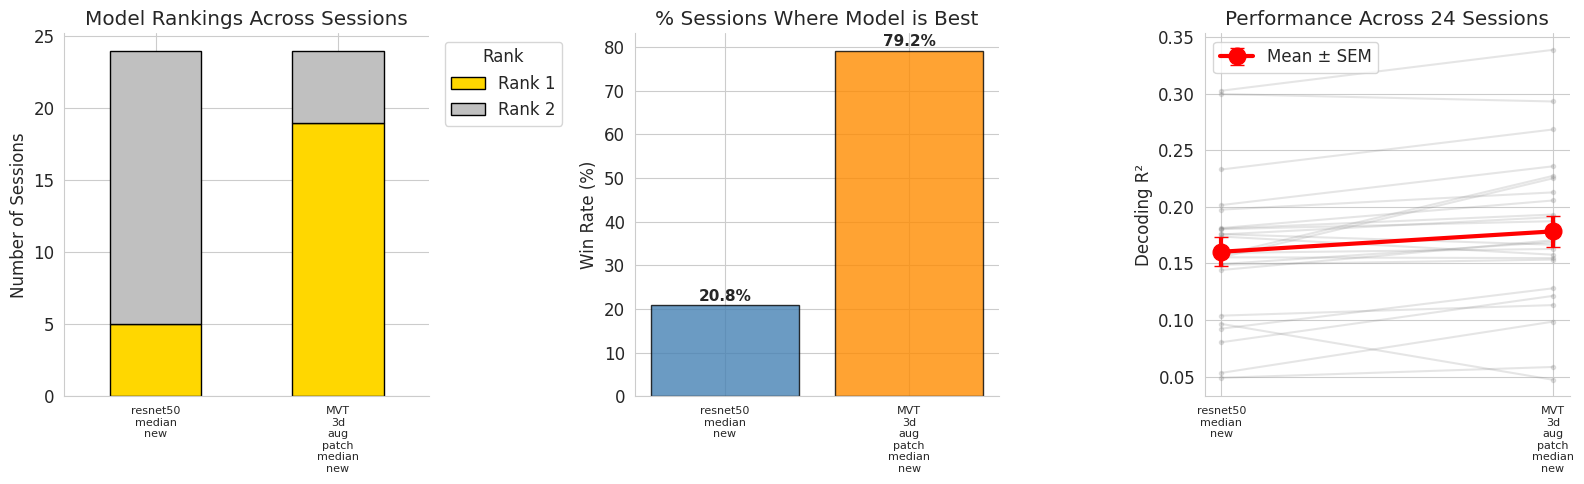


=== Summary ===
Model                               Mean R²      Win Rate     Mean Rank   
----------------------------------------------------------------------
resnet50_median_new                 0.1603       20.8        % 1.79        
MVT_3d_aug_patch_median_new         0.1784       79.2        % 1.21        


In [17]:
def plot_model_ranking(base_path, eids, target, pose_models):
    """
    Shows how often each model ranks 1st, 2nd, 3rd across sessions.
    """
    session_results = []
    
    for eid in eids:
        res_dict = load_session_results(base_path, eid, target, pose_models)
        
        row = {'eid': eid}
        for m in pose_models:
            if m in res_dict:
                y = res_dict[m]['y_flattened']
                pred = res_dict[m]['pred_flattened']
                row[m] = r2_score(y, pred)
        
        if len(row) == len(pose_models) + 1:
            session_results.append(row)
    
    df = pd.DataFrame(session_results)
    
    # Compute ranks per session (1 = best)
    rank_df = df[pose_models].rank(axis=1, ascending=False)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Plot 1: Rank distribution (stacked bar)
    ax = axes[0]
    rank_counts = pd.DataFrame({m: rank_df[m].value_counts().sort_index() for m in pose_models})
    rank_counts = rank_counts.fillna(0).T
    rank_counts.columns = [f'Rank {int(c)}' for c in rank_counts.columns]
    
    colors = ['gold', 'silver', 'brown'][:len(pose_models)]
    rank_counts.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='black')
    ax.set_ylabel('Number of Sessions')
    ax.set_title('Model Rankings Across Sessions')
    ax.set_xticklabels([m.replace('_', '\n') for m in pose_models], rotation=0, fontsize=8)
    ax.legend(title='Rank', bbox_to_anchor=(1.02, 1))
    sns.despine(ax=ax)
    
    # Plot 2: Win rate (% sessions where model is best)
    ax = axes[1]
    win_rates = [(rank_df[m] == 1).mean() * 100 for m in pose_models]
    bars = ax.bar(pose_models, win_rates, color=['steelblue', 'darkorange', 'green'][:len(pose_models)],
                  edgecolor='black', alpha=0.8)
    ax.set_ylabel('Win Rate (%)')
    ax.set_title('% Sessions Where Model is Best')
    ax.set_xticklabels([m.replace('_', '\n') for m in pose_models], rotation=0, fontsize=8)
    
    # Add percentage labels on bars
    for bar, rate in zip(bars, win_rates):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{rate:.1f}%', ha='center', fontsize=11, fontweight='bold')
    sns.despine(ax=ax)
    
    # Plot 3: Mean R² with individual sessions
    ax = axes[2]
    x = np.arange(len(pose_models))
    
    # Individual sessions (gray lines)
    for _, row in df.iterrows():
        values = [row[m] for m in pose_models]
        ax.plot(x, values, 'o-', color='gray', alpha=0.2, markersize=3)
    
    # Mean with error bars
    means = [df[m].mean() for m in pose_models]
    sems = [df[m].std() / np.sqrt(len(df)) for m in pose_models]
    ax.errorbar(x, means, yerr=sems, fmt='o-', color='red', linewidth=3, 
                markersize=12, capsize=5, label='Mean ± SEM')
    
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace('_', '\n') for m in pose_models], fontsize=8)
    ax.set_ylabel('Decoding R²')
    ax.set_title(f'Performance Across {len(df)} Sessions')
    ax.legend()
    sns.despine(ax=ax)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n=== Summary ===")
    print(f"{'Model':<35} {'Mean R²':<12} {'Win Rate':<12} {'Mean Rank':<12}")
    print("-" * 70)
    for m in pose_models:
        print(f"{m:<35} {df[m].mean():<12.4f} {(rank_df[m]==1).mean()*100:<12.1f}% {rank_df[m].mean():<12.2f}")
    
    return df, rank_df


df, rank_df = plot_model_ranking(base_path, eids, target, pose_models)


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15763234-d21e-491f-a01b-1238eb96d389
  Trials: 349
  R² (flattened): 0.158
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new


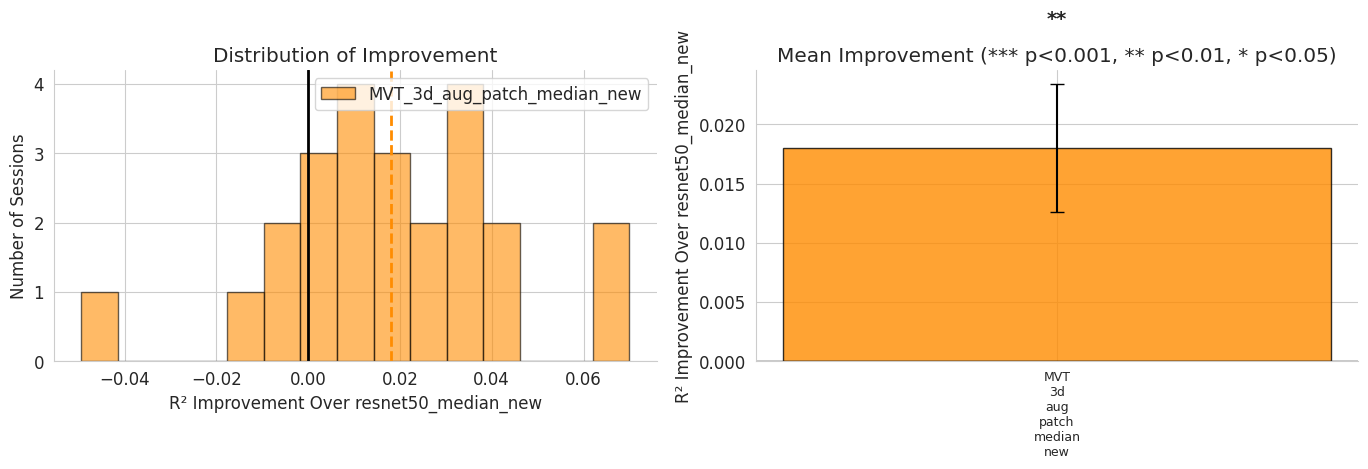


=== Improvement Over resnet50_median_new ===

MVT_3d_aug_patch_median_new: ΔR² = 0.0180 ± 0.0054, p = 0.0029


In [18]:
def plot_improvement_over_baseline(base_path, eids, target, pose_models, baseline_model=None):
    """
    Shows improvement of each model relative to baseline.
    """
    if baseline_model is None:
        baseline_model = pose_models[0]
    
    session_results = []
    
    for eid in eids:
        res_dict = load_session_results(base_path, eid, target, pose_models)
        
        row = {'eid': eid}
        for m in pose_models:
            if m in res_dict:
                y = res_dict[m]['y_flattened']
                pred = res_dict[m]['pred_flattened']
                row[m] = r2_score(y, pred)
        
        if len(row) == len(pose_models) + 1:
            session_results.append(row)
    
    df = pd.DataFrame(session_results)
    
    # Compute improvement over baseline
    other_models = [m for m in pose_models if m != baseline_model]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Improvement distribution
    ax = axes[0]
    colors = ['darkorange', 'green', 'purple'][:len(other_models)]
    
    for i, m in enumerate(other_models):
        diff = df[m] - df[baseline_model]
        ax.hist(diff, bins=15, alpha=0.6, label=f'{m}', color=colors[i], edgecolor='black')
        ax.axvline(diff.mean(), color=colors[i], linestyle='--', linewidth=2)
    
    ax.axvline(0, color='black', linestyle='-', linewidth=2)
    ax.set_xlabel(f'R² Improvement Over {baseline_model}')
    ax.set_ylabel('Number of Sessions')
    ax.set_title('Distribution of Improvement')
    ax.legend()
    sns.despine(ax=ax)
    
    # Plot 2: Improvement bar plot with significance
    ax = axes[1]
    from scipy import stats
    
    improvements = []
    sems = []
    p_values = []
    
    for m in other_models:
        diff = df[m] - df[baseline_model]
        improvements.append(diff.mean())
        sems.append(diff.std() / np.sqrt(len(diff)))
        _, p = stats.ttest_rel(df[m], df[baseline_model])
        p_values.append(p)
    
    x = np.arange(len(other_models))
    bars = ax.bar(x, improvements, yerr=sems, capsize=5, 
                  color=colors[:len(other_models)], edgecolor='black', alpha=0.8)
    ax.axhline(0, color='black', linestyle='-', linewidth=1)
    
    # Add significance stars
    for i, (bar, p) in enumerate(zip(bars, p_values)):
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        height = bar.get_height() + sems[i]
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.005, stars, 
                ha='center', fontsize=14, fontweight='bold')
    
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace('_', '\n') for m in other_models], fontsize=9)
    ax.set_ylabel(f'R² Improvement Over {baseline_model}')
    ax.set_title('Mean Improvement (*** p<0.001, ** p<0.01, * p<0.05)')
    sns.despine(ax=ax)
    
    plt.tight_layout()
    plt.show()
    
    # Print stats
    print(f"\n=== Improvement Over {baseline_model} ===\n")
    for m, imp, sem, p in zip(other_models, improvements, sems, p_values):
        print(f"{m}: ΔR² = {imp:.4f} ± {sem:.4f}, p = {p:.4f}")
    
    return df


df = plot_improvement_over_baseline(base_path, eids, target, pose_models, baseline_model='resnet50_median_new')



Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15763234-d21e-491f-a01b-1238eb96d389
  Trials: 349
  R² (flattened): 0.158
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new


/tmp/ipykernel_2386396/2546340999.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


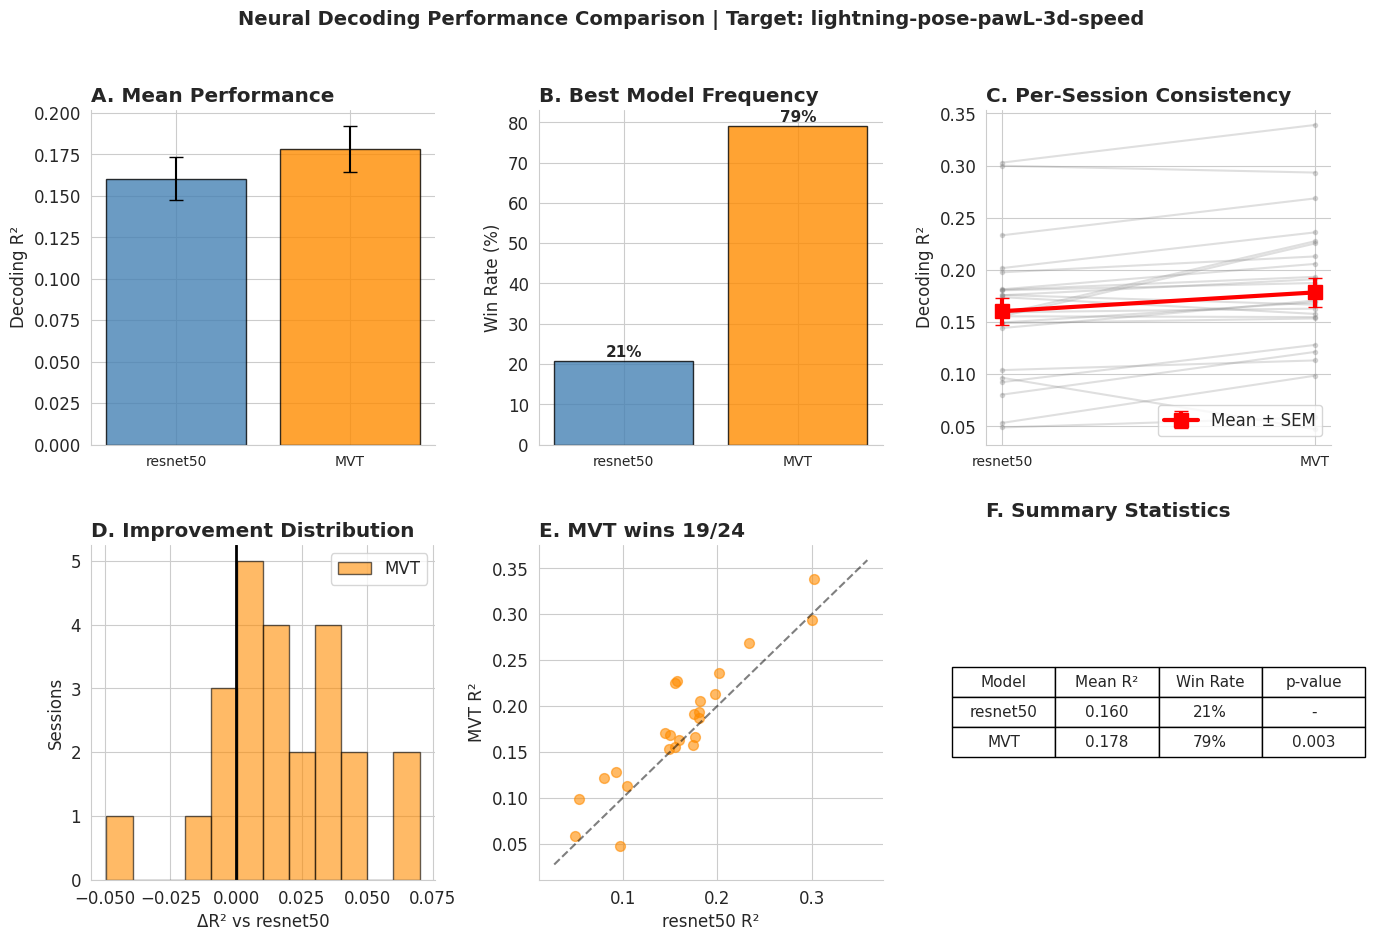

In [19]:
def plot_publication_figure(base_path, eids, target, pose_models, baseline_model=None):
    """
    Combined publication-ready figure.
    """
    if baseline_model is None:
        baseline_model = pose_models[0]
    
    session_results = []
    
    for eid in eids:
        res_dict = load_session_results(base_path, eid, target, pose_models)
        
        row = {'eid': eid}
        for m in pose_models:
            if m in res_dict:
                y = res_dict[m]['y_flattened']
                pred = res_dict[m]['pred_flattened']
                row[m] = r2_score(y, pred)
        
        if len(row) == len(pose_models) + 1:
            session_results.append(row)
    
    df = pd.DataFrame(session_results)
    rank_df = df[pose_models].rank(axis=1, ascending=False)
    
    from scipy import stats
    
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
    
    colors = {'resnet50_median_new': 'steelblue', 
              'MVT_3d_aug_patch_median_new': 'darkorange',
              'model3': 'green'}  # Add your third model
    
    # A: Bar plot with error bars
    ax = fig.add_subplot(gs[0, 0])
    x = np.arange(len(pose_models))
    means = [df[m].mean() for m in pose_models]
    sems = [df[m].std() / np.sqrt(len(df)) for m in pose_models]
    
    bars = ax.bar(x, means, yerr=sems, capsize=5, 
                  color=[colors.get(m, 'gray') for m in pose_models],
                  edgecolor='black', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([m.split('_')[0] for m in pose_models], fontsize=10)
    ax.set_ylabel('Decoding R²')
    ax.set_title('A. Mean Performance', fontweight='bold', loc='left')
    sns.despine(ax=ax)
    
    # B: Win rate
    ax = fig.add_subplot(gs[0, 1])
    win_rates = [(rank_df[m] == 1).mean() * 100 for m in pose_models]
    bars = ax.bar(x, win_rates, color=[colors.get(m, 'gray') for m in pose_models],
                  edgecolor='black', alpha=0.8)
    for bar, rate in zip(bars, win_rates):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{rate:.0f}%', ha='center', fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([m.split('_')[0] for m in pose_models], fontsize=10)
    ax.set_ylabel('Win Rate (%)')
    ax.set_title('B. Best Model Frequency', fontweight='bold', loc='left')
    sns.despine(ax=ax)
    
    # C: Per-session paired lines
    ax = fig.add_subplot(gs[0, 2])
    for _, row in df.iterrows():
        values = [row[m] for m in pose_models]
        ax.plot(x, values, 'o-', color='gray', alpha=0.25, markersize=3)
    ax.errorbar(x, means, yerr=sems, fmt='s-', color='red', linewidth=3,
                markersize=10, capsize=5, label='Mean ± SEM', zorder=10)
    ax.set_xticks(x)
    ax.set_xticklabels([m.split('_')[0] for m in pose_models], fontsize=10)
    ax.set_ylabel('Decoding R²')
    ax.set_title('C. Per-Session Consistency', fontweight='bold', loc='left')
    ax.legend(loc='lower right')
    sns.despine(ax=ax)
    
    # D: Improvement over baseline
    ax = fig.add_subplot(gs[1, 0])
    other_models = [m for m in pose_models if m != baseline_model]
    
    for i, m in enumerate(other_models):
        diff = df[m] - df[baseline_model]
        ax.hist(diff, bins=12, alpha=0.6, label=m.split('_')[0], 
                color=colors.get(m, 'gray'), edgecolor='black')
    ax.axvline(0, color='black', linestyle='-', linewidth=2)
    ax.set_xlabel(f'ΔR² vs {baseline_model.split("_")[0]}')
    ax.set_ylabel('Sessions')
    ax.set_title('D. Improvement Distribution', fontweight='bold', loc='left')
    ax.legend()
    sns.despine(ax=ax)
    
    # E: Pairwise scatter
    ax = fig.add_subplot(gs[1, 1])
    if len(other_models) >= 1:
        m = other_models[0]  # Compare first non-baseline to baseline
        ax.scatter(df[baseline_model], df[m], alpha=0.6, s=50, color=colors.get(m, 'gray'))
        lims = [min(df[baseline_model].min(), df[m].min()) - 0.02,
                max(df[baseline_model].max(), df[m].max()) + 0.02]
        ax.plot(lims, lims, 'k--', alpha=0.5)
        ax.set_xlabel(f'{baseline_model.split("_")[0]} R²')
        ax.set_ylabel(f'{m.split("_")[0]} R²')
        wins = (df[m] > df[baseline_model]).sum()
        ax.set_title(f'E. {m.split("_")[0]} wins {wins}/{len(df)}', fontweight='bold', loc='left')
    sns.despine(ax=ax)
    
    # F: Summary statistics table
    ax = fig.add_subplot(gs[1, 2])
    ax.axis('off')
    
    # Create table data
    table_data = []
    for m in pose_models:
        t_stat, p_val = stats.ttest_rel(df[m], df[baseline_model]) if m != baseline_model else (0, 1)
        table_data.append([
            m.split('_')[0],
            f'{df[m].mean():.3f}',
            f'{(rank_df[m]==1).mean()*100:.0f}%',
            f'{p_val:.3f}' if m != baseline_model else '-'
        ])
    
    table = ax.table(cellText=table_data,
                     colLabels=['Model', 'Mean R²', 'Win Rate', 'p-value'],
                     loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 1.8)
    ax.set_title('F. Summary Statistics', fontweight='bold', loc='left', pad=20)
    
    plt.suptitle(f'Neural Decoding Performance Comparison | Target: {target}', 
                 fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    
    return df


df = plot_publication_figure(base_path, eids, target, pose_models, baseline_model='resnet50_median_new')


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15763234-d21e-491f-a01b-1238eb96d389
  Trials: 349
  R² (flattened): 0.158
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new


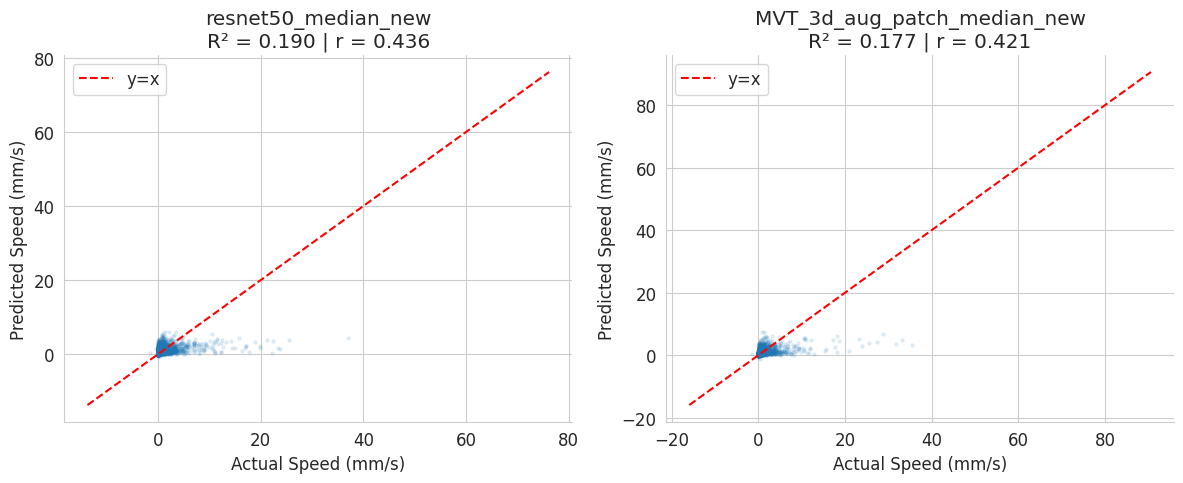

In [ ]:
def plot_paired_session_comparison(base_path, eids, target, pose_models):
    """
    Paired comparison for multiple models showing which model wins per session.
    """
    session_results = []
    
    for eid in eids:
        res_dict = load_session_results(base_path, eid, target, pose_models)
        
        row = {'eid': eid}
        for m in pose_models:
            if m in res_dict:
                y = res_dict[m]['y_flattened']
                pred = res_dict[m]['pred_flattened']
                row[m] = r2_score(y, pred)
        
        if len(row) == len(pose_models) + 1:  # All models present
            session_results.append(row)
    
    df = pd.DataFrame(session_results)
    
    n_models = len(pose_models)
    n_pairs = n_models * (n_models - 1) // 2  # Number of pairwise comparisons
    
    fig, axes = plt.subplots(2, n_pairs, figsize=(6*n_pairs, 10))
    if n_pairs == 1:
        axes = axes.reshape(2, 1)
    
    pair_idx = 0
    from scipy import stats
    
    print("=== Pairwise Comparisons ===\n")
    
    for i in range(n_models):
        for j in range(i+1, n_models):
            m1, m2 = pose_models[i], pose_models[j]
            
            # Top row: Scatter plot
            ax = axes[0, pair_idx]
            ax.scatter(df[m1], df[m2], alpha=0.7, s=50)
            lims = [min(df[m1].min(), df[m2].min()) - 0.02,
                    max(df[m1].max(), df[m2].max()) + 0.02]
            ax.plot(lims, lims, 'k--', alpha=0.5)
            ax.set_xlabel(f'{m1} R²')
            ax.set_ylabel(f'{m2} R²')
            
            # Count wins
            m2_wins = (df[m2] > df[m1]).sum()
            ax.set_title(f'{m2} wins: {m2_wins}/{len(df)} sessions')
            sns.despine(ax=ax)
            
            # Bottom row: Histogram of differences
            ax = axes[1, pair_idx]
            diff = df[m2] - df[m1]
            ax.hist(diff, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
            ax.axvline(0, color='red', linestyle='--', lw=2)
            ax.axvline(diff.mean(), color='green', linestyle='-', lw=2, 
                       label=f'Mean = {diff.mean():.4f}')
            ax.set_xlabel(f'R² Difference ({m2} - {m1})')
            ax.set_ylabel('Number of Sessions')
            ax.legend()
            sns.despine(ax=ax)
            
            # Stats
            t_stat, p_val = stats.ttest_rel(df[m2], df[m1])
            print(f"{m2} vs {m1}:")
            print(f"  Mean diff = {diff.mean():.4f}, t = {t_stat:.3f}, p = {p_val:.4f}")
            print(f"  {m2} wins {m2_wins}/{len(df)} sessions\n")
            
            pair_idx += 1
    
    plt.tight_layout()
    plt.show()
    
    return df


df = plot_paired_session_comparison(base_path, eids, target, pose_models)

In [10]:
def diagnose_low_variance_bins(base_path, eids, target, pose_models, n_bins=10):
    """
    Diagnose why low variance bins have negative R².
    """
    agg_data = {m: {'y': [], 'pred': [], 'var': []} for m in pose_models}
    
    for eid in eids:
        res_dict = load_session_results(base_path, eid, target, pose_models)
        for m in pose_models:
            if m in res_dict and 'avg_ens_var_flattened' in res_dict[m]:
                agg_data[m]['y'].append(res_dict[m]['y_flattened'])
                agg_data[m]['pred'].append(res_dict[m]['pred_flattened'])
                agg_data[m]['var'].append(res_dict[m]['avg_ens_var_flattened'])
    
    # Concatenate
    for m in pose_models:
        agg_data[m]['y'] = np.concatenate(agg_data[m]['y'])
        agg_data[m]['pred'] = np.concatenate(agg_data[m]['pred'])
        agg_data[m]['var'] = np.concatenate(agg_data[m]['var'])
    
    shared_vars = [agg_data[m]['var'] for m in pose_models]
    shared_var_scale = np.mean(shared_vars, axis=0)
    
    percentiles = np.linspace(0, 100, n_bins + 1)
    thresholds = np.percentile(shared_var_scale, percentiles)
    thresholds[-1] += 1e-9
    
    m = pose_models[0]  # Check first model
    
    print("=== Diagnosis by Variance Bin ===\n")
    print(f"{'Bin':<10} {'N':<8} {'Mean Y':<10} {'Std Y':<10} {'Mean Pred':<10} {'R²':<10}")
    print("-" * 60)
    
    for j in range(n_bins):
        mask = (shared_var_scale >= thresholds[j]) & (shared_var_scale < thresholds[j+1])
        
        y_bin = agg_data[m]['y'][mask]
        pred_bin = agg_data[m]['pred'][mask]
        
        if len(y_bin) < 2:
            continue
        
        r2 = r2_score(y_bin, pred_bin)
        
        print(f"{j*10}-{(j+1)*10}%    {len(y_bin):<8} {np.mean(y_bin):<10.4f} {np.std(y_bin):<10.4f} {np.mean(pred_bin):<10.4f} {r2:<10.4f}")


diagnose_low_variance_bins(base_path, eids, target, pose_models)


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15763234-d21e-491f-a01b-1238eb96d389
  Trials: 349
  R² (flattened): 0.158
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new



Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15763234-d21e-491f-a01b-1238eb96d389
  Trials: 349
  R² (flattened): 0.158
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: aad23144-0e52-4eac-80c5-c4ee2decb198
  Trials: 372
  R² (flattened): 0.202
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightn

/tmp/ipykernel_2372958/170926472.py:26: RuntimeWarning: invalid value encountered in sqrt
  std_dev = np.sqrt(res['avg_ens_var_flattened'])
/tmp/ipykernel_2372958/170926472.py:26: RuntimeWarning: invalid value encountered in sqrt
  std_dev = np.sqrt(res['avg_ens_var_flattened'])
/tmp/ipykernel_2372958/170926472.py:26: RuntimeWarning: invalid value encountered in sqrt
  std_dev = np.sqrt(res['avg_ens_var_flattened'])
/tmp/ipykernel_2372958/170926472.py:26: RuntimeWarning: invalid value encountered in sqrt
  std_dev = np.sqrt(res['avg_ens_var_flattened'])
/tmp/ipykernel_2372958/170926472.py:26: RuntimeWarning: invalid value encountered in sqrt
  std_dev = np.sqrt(res['avg_ens_var_flattened'])
/tmp/ipykernel_2372958/170926472.py:26: RuntimeWarning: invalid value encountered in sqrt
  std_dev = np.sqrt(res['avg_ens_var_flattened'])
/tmp/ipykernel_2372958/170926472.py:26: RuntimeWarning: invalid value encountered in sqrt
  std_dev = np.sqrt(res['avg_ens_var_flattened'])
/tmp/ipykernel_23729

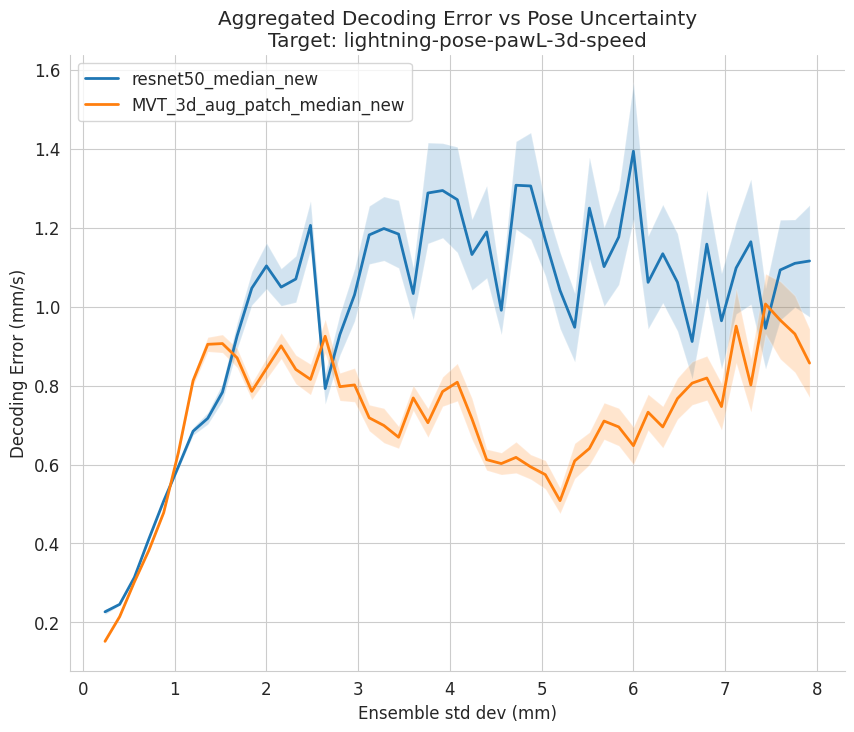

In [10]:
def plot_decoding_error_vs_std_all_sessions(base_path, eids, target, pose_models, n_bins=50, max_std=8):
    """
    Aggregates all sessions and plots absolute error vs ensemble std dev.
    """
    plt.figure(figsize=(10, 8))
    
    # Determine units for the label
    # If 3D, it's usually mm/s or m/s. If 2D, it's pixels/s.
    unit_label = "mm/s" if "3d" in target.lower() else "pix/s"
    
    bins = np.linspace(0, max_std, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    for m_name in pose_models:
        all_errors, all_stds = [], []
        for eid in eids:
            res_dict = load_session_results(base_path, eid, target, [m_name])
            if m_name in res_dict and 'avg_ens_var_flattened' in res_dict[m_name]:
                res = res_dict[m_name]
                
                # y_true and y_pred are already in the target units (e.g., mm/s)
                # because we disabled min-max normalization for lightning-pose
                error = np.abs(res['y_flattened'] - res['pred_flattened'])
                
                # Ensemble std is also in the same physical units (mm or pixels)
                std_dev = np.sqrt(res['avg_ens_var_flattened'])
                
                all_errors.append(error)
                all_stds.append(std_dev)
        
        if not all_errors: continue
        
        errors = np.concatenate(all_errors)
        stds = np.concatenate(all_stds)
        
        means, sems = [], []
        for i in range(n_bins):
            mask = (stds >= bins[i]) & (stds < bins[i+1])
            if np.sum(mask) > 50:
                means.append(np.mean(errors[mask]))
                sems.append(sem(errors[mask]))
            else:
                means.append(np.nan); sems.append(np.nan)
        
        plt.plot(bin_centers, means, label=m_name, linewidth=2)
        plt.fill_between(bin_centers, np.array(means)-np.array(sems), np.array(means)+np.array(sems), alpha=0.2)

    plt.xlabel(f'Ensemble std dev ({unit_label.split("/")[0]})') # e.g., "mm" or "pix"
    plt.ylabel(f'Decoding Error ({unit_label})')               # e.g., "mm/s" or "pix/s"
    plt.title(f'Aggregated Decoding Error vs Pose Uncertainty\nTarget: {target}')
    plt.legend()
    sns.despine()
    plt.show()

plot_decoding_error_vs_std_all_sessions(base_path, eids, target, pose_models)

Plotting Session PSTH for EID: 15763234-d21e-491f-a01b-1238eb96d389

  resnet50_median_new:
    Single-Trial R²:    0.1577  <-- USE THIS
    Mean Trial R²:      -246.7030 ± 1093.9052
    Pearson Correlation: 0.3995
    PSTH R² (inflated): 0.9995

  MVT_3d_aug_patch_median_new:
    Single-Trial R²:    0.2275  <-- USE THIS
    Mean Trial R²:      -212.4853 ± 642.0235
    Pearson Correlation: 0.4814
    PSTH R² (inflated): 0.9997



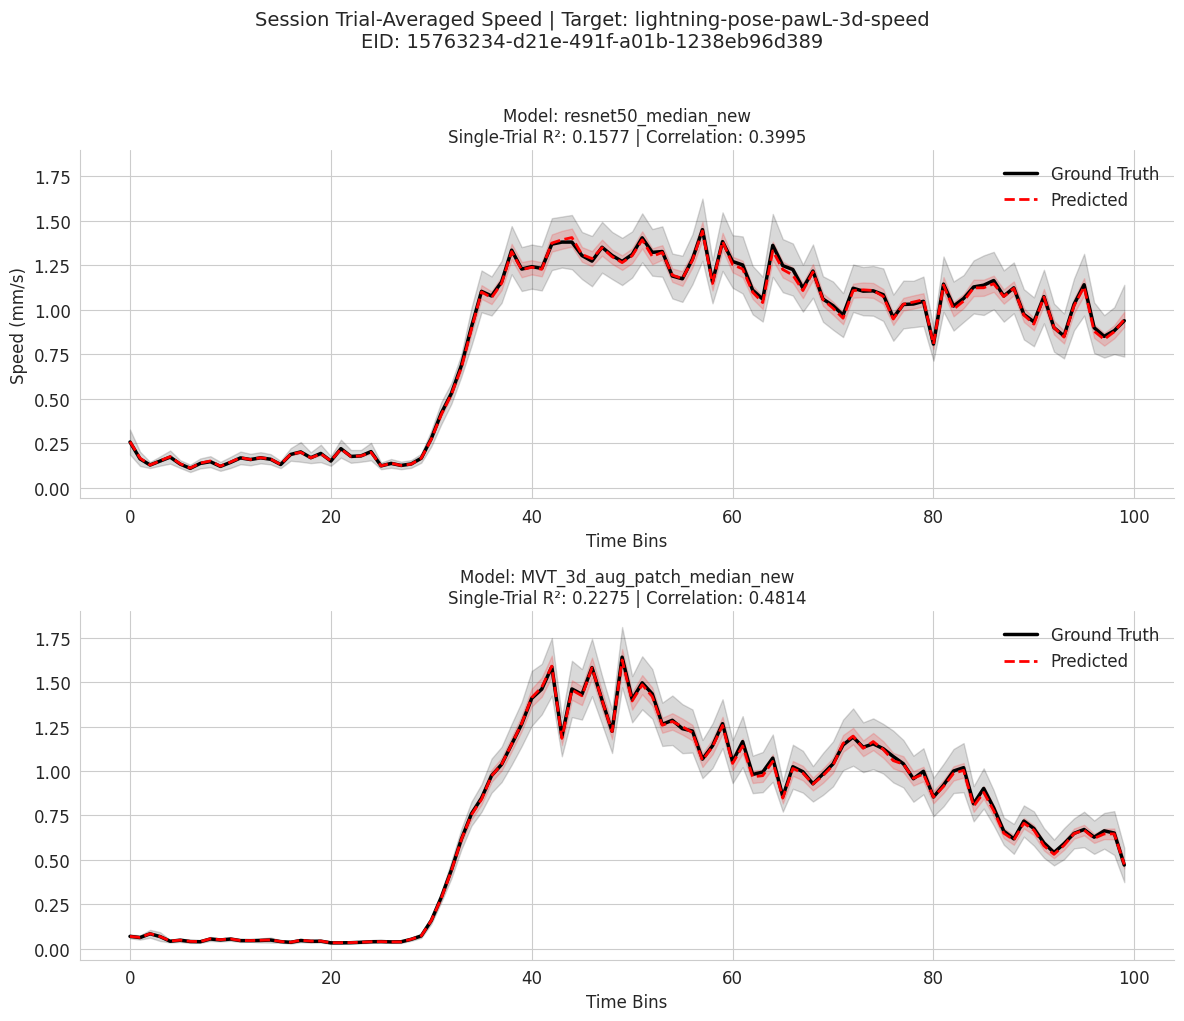

,model,r2_single_trial,r2_trial_mean,r2_trial_std,correlation,r2_psth
0,resnet50_median_new,0.157659,-246.702990,1093.905249,0.399549,0.999538
1,MVT_3d_aug_patch_median_new,0.227462,-212.485319,642.023466,0.481364,0.999716


In [14]:
def plot_session_psth_comparison(base_path, eid, target, pose_models):
    """
    Plots the PSTH (Trial Average) for all pose models for a single session.
    """
    n_models = len(pose_models)
    fig, axes = plt.subplots(n_models, 1, figsize=(12, 5 * n_models), sharey=True)
    if n_models == 1:
        axes = [axes]
    
    print(f"Plotting Session PSTH for EID: {eid}\n")
    
    results = []
    
    for ax, m_name in zip(axes, pose_models):
        path = f"{base_path}/{eid}/{target}/{m_name}/linear/all/{eid}_cv.npy"
        
        if not os.path.exists(path):
            print(f"  [!] Missing: {m_name}")
            continue
        
        data = np.load(path, allow_pickle=True).item()
        y = data['all_test_y']       # (n_trials, 100)
        pred = data['all_test_pred'] # (n_trials, 100)
        
        # === KEY METRICS ===
        
        # 1. Single-trial R² (most important!)
        r2_single = r2_score(y.flatten(), pred.flatten())
        
        # 2. Mean R² per trial (alternative view)
        r2_per_trial = [r2_score(y[i], pred[i]) for i in range(len(y))]
        r2_trial_mean = np.mean(r2_per_trial)
        r2_trial_std = np.std(r2_per_trial)
        
        # 3. Correlation (Pearson) - less sensitive to scale
        corr_single = np.corrcoef(y.flatten(), pred.flatten())[0, 1]
        
        # 4. PSTH metrics (for visualization, not comparison)
        mean_y = np.mean(y, axis=0)
        mean_p = np.mean(pred, axis=0)
        r2_psth = r2_score(mean_y, mean_p)
        
        # Store results
        results.append({
            'model': m_name,
            'r2_single_trial': r2_single,
            'r2_trial_mean': r2_trial_mean,
            'r2_trial_std': r2_trial_std,
            'correlation': corr_single,
            'r2_psth': r2_psth
        })
        
        # Print detailed metrics
        print(f"  {m_name}:")
        print(f"    Single-Trial R²:    {r2_single:.4f}  <-- USE THIS")
        print(f"    Mean Trial R²:      {r2_trial_mean:.4f} ± {r2_trial_std:.4f}")
        print(f"    Pearson Correlation: {corr_single:.4f}")
        print(f"    PSTH R² (inflated): {r2_psth:.4f}\n")
        
        # Calculate SEM for shaded area
        sem_y = np.std(y, axis=0) / np.sqrt(y.shape[0])
        sem_p = np.std(pred, axis=0) / np.sqrt(pred.shape[0])
        
        time_bins = np.arange(len(mean_y))
        
        # Plot
        ax.plot(time_bins, mean_y, color='black', label='Ground Truth', lw=2.5)
        ax.fill_between(time_bins, mean_y - sem_y, mean_y + sem_y, color='black', alpha=0.15)
        ax.plot(time_bins, mean_p, color='red', linestyle='--', label='Predicted', lw=2)
        ax.fill_between(time_bins, mean_p - sem_p, mean_p + sem_p, color='red', alpha=0.15)
        
        # Title with meaningful metric
        ax.set_title(f"Model: {m_name}\nSingle-Trial R²: {r2_single:.4f} | Correlation: {corr_single:.4f}", 
                     fontsize=12)
        ax.set_xlabel("Time Bins")
        
        if ax == axes[0]:
            unit = "mm/s" if "3d" in target.lower() else "pix/s"
            ax.set_ylabel(f"Speed ({unit})")
        
        ax.legend(frameon=False)
        sns.despine(ax=ax)
    
    plt.suptitle(f"Session Trial-Averaged Speed | Target: {target}\nEID: {eid}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame(results)

plot_session_psth_comparison(base_path,eid,target,pose_models)

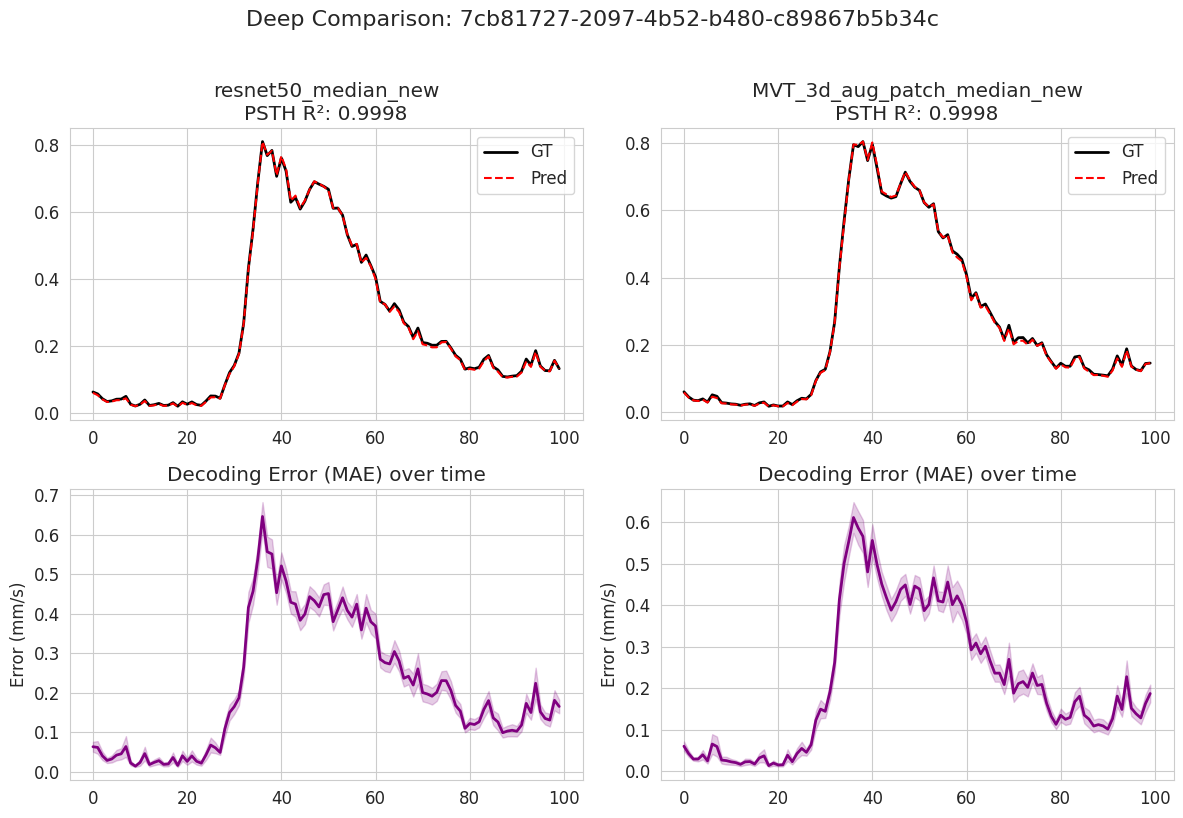

In [731]:
def plot_session_detailed_differences(base_path, eid, target, pose_models):
    n_models = len(pose_models)
    # Row 1: PSTH (Speed)
    # Row 2: Mean Absolute Error (The "Residuals")
    # Row 3: Distribution of Trial-by-Trial R2
    fig, axes = plt.subplots(2, n_models, figsize=(6 * n_models, 8), sharex='row')
    if n_models == 1: axes = [[ax] for ax in axes]

    for col_idx, m_name in enumerate(pose_models):
        path = f"{base_path}/{eid}/{target}/{m_name}/linear/all/{eid}_cv.npy"
        data = np.load(path, allow_pickle=True).item()
        y = data['all_test_y']
        pred = data['all_test_pred']
        
        # --- ROW 1: PSTH (Standard View) ---
        ax_psth = axes[0][col_idx]
        m_y, m_p = np.mean(y, axis=0), np.mean(pred, axis=0)
        ax_psth.plot(m_y, color='black', label='GT', lw=2)
        ax_psth.plot(m_p, color='red', linestyle='--', label='Pred', lw=1.5)
        ax_psth.set_title(f"{m_name}\nPSTH R²: {r2_score(m_y, m_p):.4f}")
        ax_psth.legend()

        # --- ROW 2: Mean Absolute Error (MAE) ---
        # This shows WHERE in the trial the decoder is struggling most
        ax_error = axes[1][col_idx]
        errors = np.abs(y - pred)
        mean_error = np.mean(errors, axis=0)
        sem_error = np.std(errors, axis=0) / np.sqrt(len(y))
        
        ax_error.plot(mean_error, color='purple', lw=2)
        ax_error.fill_between(range(100), mean_error - sem_error, mean_error + sem_error, color='purple', alpha=0.2)
        ax_error.set_title("Decoding Error (MAE) over time")
        ax_error.set_ylabel("Error (mm/s)")


    plt.suptitle(f"Deep Comparison: {eid}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Run the detailed comparison
plot_session_detailed_differences(base_path, eid, target, pose_models)


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15763234-d21e-491f-a01b-1238eb96d389
  Trials: 349
  R² (flattened): 0.158
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new


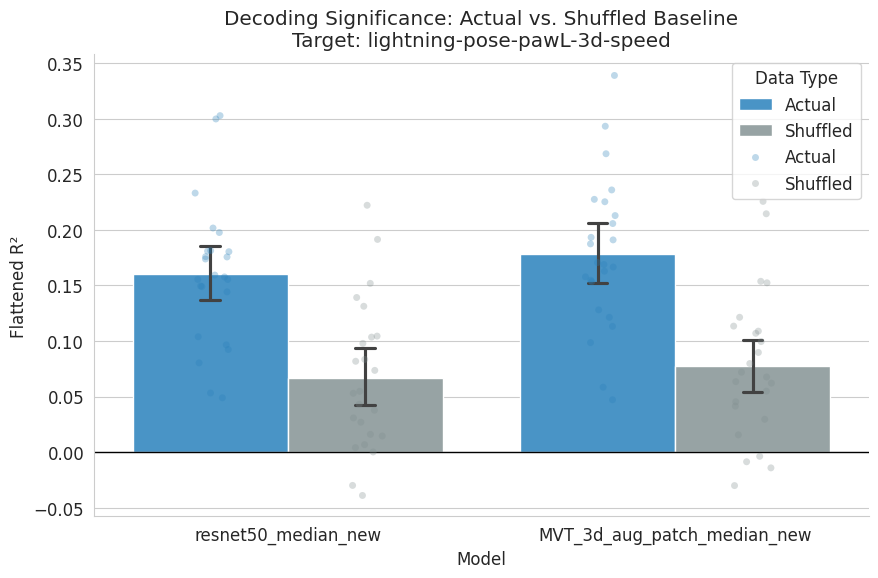

In [24]:
def plot_shuffled_baseline_comparison(base_path, eids, target, pose_models):
    """
    Compares actual R2 to a shuffled baseline to prove the decoding is real.
    """
    records = []
    
    for eid in eids:
        for m_name in pose_models:
            res_dict = load_session_results(base_path, eid, target, [m_name])
            if m_name not in res_dict: continue
            
            y = res_dict[m_name]['test_y']
            pred = res_dict[m_name]['test_pred']
            
            # 1. Actual R2
            actual_r2 = r2_score(y.flatten(), pred.flatten())
            records.append({'Model': m_name, 'Type': 'Actual', 'R2': actual_r2, 'Session': eid})
            
            # 2. Shuffled R2 (Shuffle trial order)
            y_shuffled = y[np.random.permutation(len(y))]
            shuffled_r2 = r2_score(y_shuffled.flatten(), pred.flatten())
            records.append({'Model': m_name, 'Type': 'Shuffled', 'R2': shuffled_r2, 'Session': eid})

    df = pd.DataFrame(records)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x='Model', y='R2', hue='Type', palette=['#3498db', '#95a5a6'], capsize=.1)
    sns.stripplot(data=df, x='Model', y='R2', hue='Type', dodge=True, alpha=0.3, palette=['#2980b9', '#7f8c8d'])
    
    plt.title(f"Decoding Significance: Actual vs. Shuffled Baseline\nTarget: {target}")
    plt.ylabel("Flattened R²")
    plt.axhline(0, color='black', lw=1)
    plt.legend(title="Data Type")
    sns.despine()
    plt.show()

# Run the significance test
plot_shuffled_baseline_comparison(base_path, eids, target, pose_models)

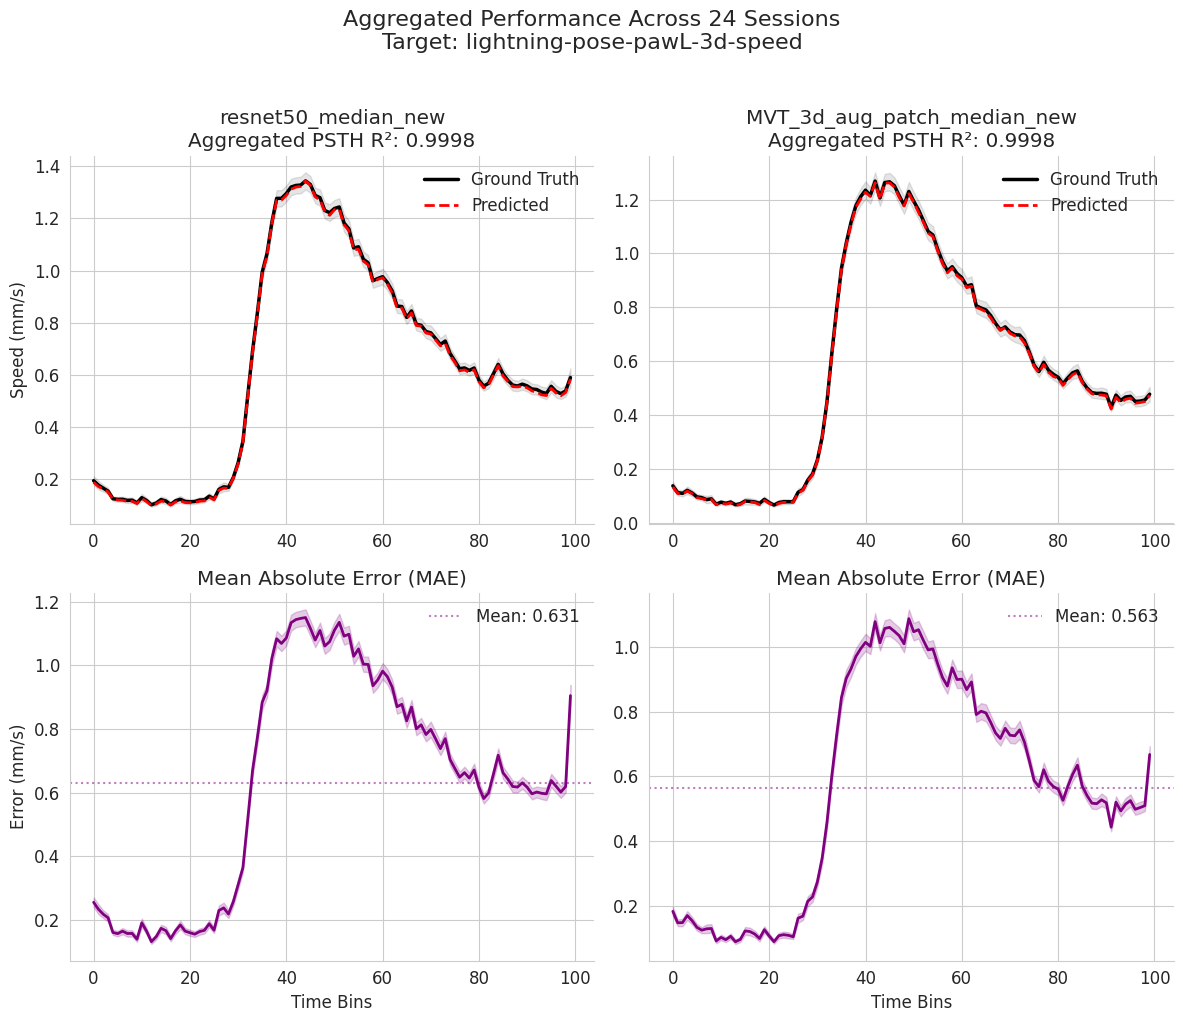

In [732]:
def plot_aggregated_psth_and_error(base_path, eids, target, pose_models):
    """
    Aggregates all trials from all sessions to show:
    1. Global PSTH (Speed)
    2. Global Decoding Error (MAE)
    """
    n_models = len(pose_models)
    fig, axes = plt.subplots(2, n_models, figsize=(6 * n_models, 10), sharex='row')
    if n_models == 1: axes = [[ax] for ax in axes]

    for col_idx, m_name in enumerate(pose_models):
        all_y = []
        all_p = []
        
        # Load and stack all sessions
        for eid in eids:
            path = f"{base_path}/{eid}/{target}/{m_name}/linear/all/{eid}_cv.npy"
            if not os.path.exists(path): continue
            
            d = np.load(path, allow_pickle=True).item()
            all_y.append(d['all_test_y'])
            all_p.append(d['all_test_pred'])
            
        if not all_y: continue
        
        # Stack into (Total Trials, 100)
        Y_STACK = np.vstack(all_y)
        P_STACK = np.vstack(all_p)
        
        # --- ROW 1: AGGREGATED PSTH ---
        ax_psth = axes[0][col_idx]
        m_y = np.mean(Y_STACK, axis=0)
        m_p = np.mean(P_STACK, axis=0)
        s_y = np.std(Y_STACK, axis=0) / np.sqrt(len(Y_STACK))
        
        ax_psth.plot(m_y, color='black', label='Ground Truth', lw=2.5)
        ax_psth.fill_between(range(100), m_y - s_y, m_y + s_y, color='black', alpha=0.1)
        ax_psth.plot(m_p, color='red', linestyle='--', label='Predicted', lw=2)
        
        psth_r2 = r2_score(m_y, m_p)
        ax_psth.set_title(f"{m_name}\nAggregated PSTH R²: {psth_r2:.4f}")
        if col_idx == 0: ax_psth.set_ylabel("Speed (mm/s)")
        ax_psth.legend(frameon=False)

        # --- ROW 2: AGGREGATED ERROR (MAE) ---
        # This shows the "residual noise" over time
        ax_err = axes[1][col_idx]
        abs_errors = np.abs(Y_STACK - P_STACK)
        m_err = np.mean(abs_errors, axis=0)
        s_err = np.std(abs_errors, axis=0) / np.sqrt(len(abs_errors))
        
        ax_err.plot(m_err, color='purple', lw=2)
        ax_err.fill_between(range(100), m_err - s_err, m_err + s_err, color='purple', alpha=0.2)
        
        # Add a horizontal line for the baseline error (average error across all time)
        ax_err.axhline(np.mean(m_err), color='purple', linestyle=':', alpha=0.5, label=f'Mean: {np.mean(m_err):.3f}')
        
        ax_err.set_title("Mean Absolute Error (MAE)")
        ax_err.set_xlabel("Time Bins")
        if col_idx == 0: ax_err.set_ylabel("Error (mm/s)")
        ax_err.legend(frameon=False)
        
        sns.despine(ax=ax_psth)
        sns.despine(ax=ax_err)

    plt.suptitle(f"Aggregated Performance Across {len(eids)} Sessions\nTarget: {target}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Run the aggregated analysis
plot_aggregated_psth_and_error(base_path, eids, target, pose_models)


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15763234-d21e-491f-a01b-1238eb96d389
  Trials: 349
  R² (flattened): 0.158
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: aad23144-0e52-4eac-80c5-c4ee2decb198
  Trials: 372
  R² (flattened): 0.202
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightn

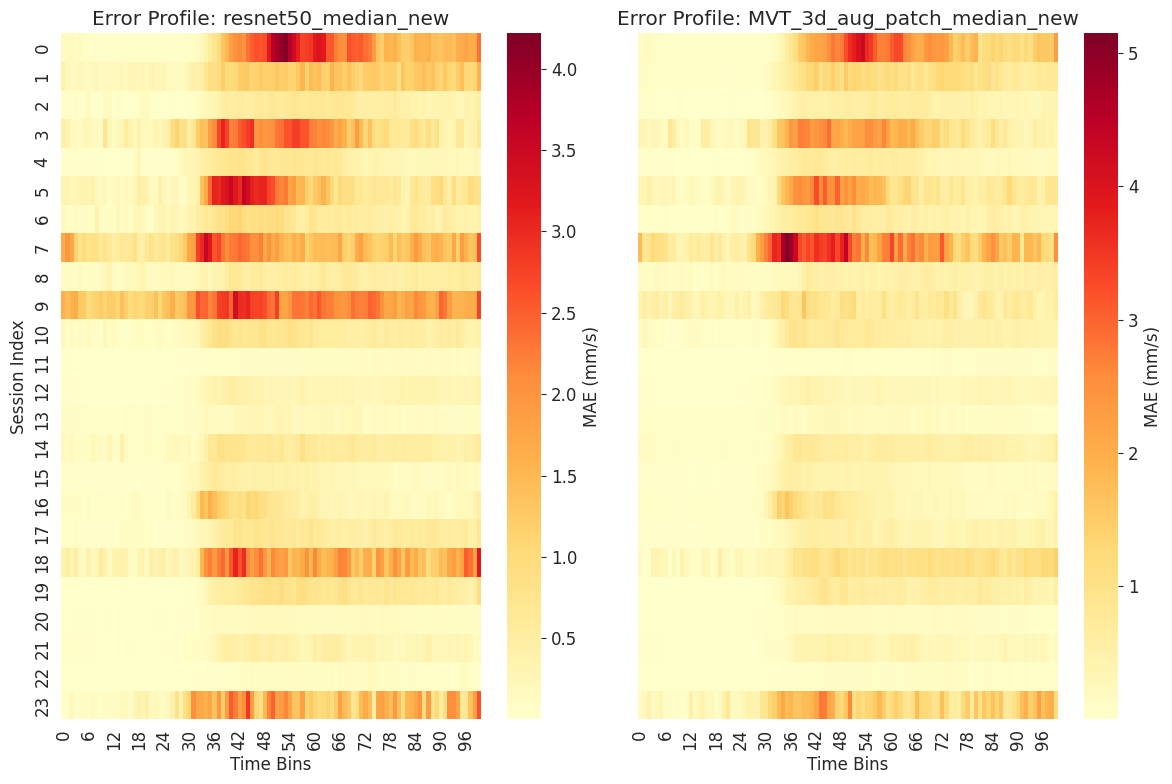

In [25]:
def plot_error_heatmap_across_sessions(base_path, eids, target, pose_models):
    n_models = len(pose_models)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 8), sharey=True)
    if n_models == 1: axes = [axes]
    
    for ax, m_name in zip(axes, pose_models):
        session_errors = []
        for eid in eids:
            res_dict = load_session_results(base_path, eid, target, [m_name])
            if m_name in res_dict:
                # Average error at each time bin for this session
                err = np.mean(np.abs(res_dict[m_name]['test_y'] - res_dict[m_name]['test_pred']), axis=0)
                session_errors.append(err)
        
        if not session_errors: continue
        sns.heatmap(np.array(session_errors), ax=ax, cmap='YlOrRd', cbar_kws={'label': 'MAE (mm/s)'})
        ax.set_title(f"Error Profile: {m_name}")
        ax.set_xlabel("Time Bins")
        if ax == axes[0]: ax.set_ylabel("Session Index")

    plt.tight_layout()
    plt.show()

plot_error_heatmap_across_sessions(base_path, eids, target, pose_models)


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15763234-d21e-491f-a01b-1238eb96d389
  Trials: 349
  R² (flattened): 0.158
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new


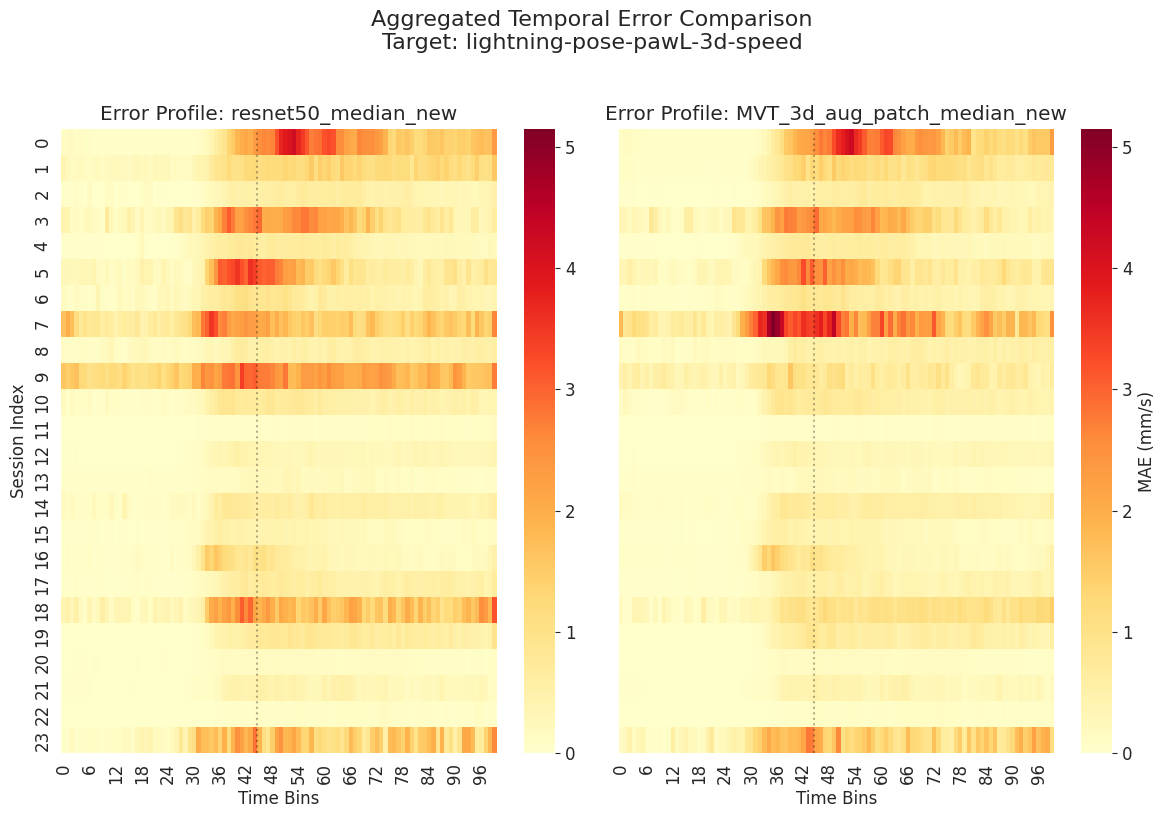

In [27]:
def plot_error_heatmap_across_sessions(base_path, eids, target, pose_models):
    """
    Plots MAE heatmaps for all models using a SHARED color scale for direct comparison.
    """
    n_models = len(pose_models)
    
    # 1. First Pass: Calculate all errors to find the global min/max for the scale
    model_data = {m: [] for m in pose_models}
    global_max = 0
    
    for eid in eids:
        for m_name in pose_models:
            res_dict = load_session_results(base_path, eid, target, [m_name])
            if m_name in res_dict:
                # Average absolute error at each time bin for this session
                err = np.mean(np.abs(res_dict[m_name]['test_y'] - res_dict[m_name]['test_pred']), axis=0)
                model_data[m_name].append(err)
                global_max = max(global_max, np.max(err))
    
    # 2. Second Pass: Plot with fixed vmin and vmax
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 8), sharey=True)
    if n_models == 1: axes = [axes]
    
    for i, m_name in enumerate(pose_models):
        ax = axes[i]
        data = np.array(model_data[m_name])
        
        if len(data) == 0: continue
            
        # Use the global_max for the color scale (vmin=0 is natural for Absolute Error)
        sns.heatmap(data, ax=ax, cmap='YlOrRd', vmin=0, vmax=global_max, 
                    cbar_kws={'label': 'MAE (mm/s)'} if i == n_models-1 else {})
        
        ax.set_title(f"Error Profile: {m_name}")
        ax.set_xlabel("Time Bins")
        if i == 0:
            ax.set_ylabel("Session Index")
        
        # Add a vertical line at the typical movement peak (around bin 45)
        ax.axvline(45, color='black', linestyle=':', alpha=0.3)

    plt.suptitle(f"Aggregated Temporal Error Comparison\nTarget: {target}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Run the synchronized heatmap
plot_error_heatmap_across_sessions(base_path, eids, target, pose_models)


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15763234-d21e-491f-a01b-1238eb96d389
  Trials: 349
  R² (flattened): 0.158
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new


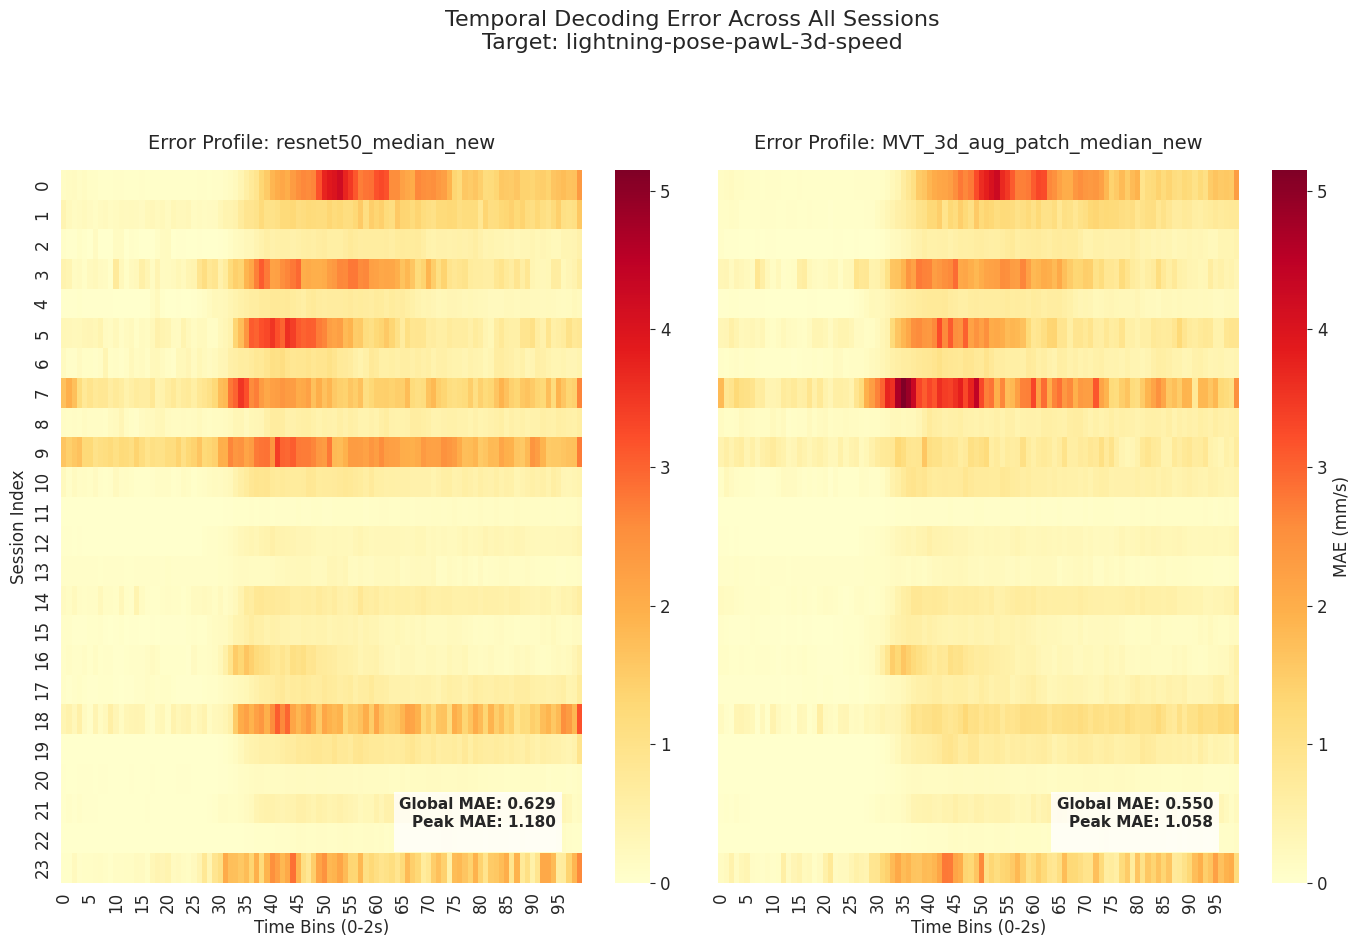

In [29]:
def plot_error_heatmap_across_sessions(base_path, eids, target, pose_models):
    """
    Plots MAE heatmaps with shared color scale and summary statistics.
    """
    n_models = len(pose_models)
    model_data = {m: [] for m in pose_models}
    global_max = 0
    
    # 1. Collect Data
    for eid in eids:
        for m_name in pose_models:
            res_dict = load_session_results(base_path, eid, target, [m_name])
            if m_name in res_dict:
                err = np.mean(np.abs(res_dict[m_name]['test_y'] - res_dict[m_name]['test_pred']), axis=0)
                model_data[m_name].append(err)
                global_max = max(global_max, np.max(err))
    
    # 2. Plot
    fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 9), sharey=True)
    if n_models == 1: axes = [axes]
    
    for i, m_name in enumerate(pose_models):
        ax = axes[i]
        data = np.array(model_data[m_name])
        if len(data) == 0: continue
            
        # Summary Statistics
        avg_mae = np.mean(data)
        peak_mae = np.max(np.mean(data, axis=0))
        session_variability = (np.std(np.mean(data, axis=1)) / avg_mae) * 100 # Coefficient of Variation %

        # Heatmap
        sns.heatmap(data, ax=ax, cmap='YlOrRd', vmin=0, vmax=global_max, 
                    cbar_kws={'label': 'MAE (mm/s)'} if i == n_models-1 else {})
        
        # Add Text Box with Numbers
        stats_text = (f"Global MAE: {avg_mae:.3f}\n"
                      f"Peak MAE: {peak_mae:.3f}\n")
        
        # Place text box in the bottom right of each heatmap
        ax.text(0.95, 0.05, stats_text, transform=ax.transAxes, 
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'),
                fontsize=11, fontweight='bold', ha='right', va='bottom')

        ax.set_title(f"Error Profile: {m_name}", fontsize=14, pad=15)
        ax.set_xlabel("Time Bins (0-2s)", fontsize=12)
        if i == 0: ax.set_ylabel("Session Index", fontsize=12)

    plt.suptitle(f"Temporal Decoding Error Across All Sessions\nTarget: {target}", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

# Run the enhanced heatmap
plot_error_heatmap_across_sessions(base_path, eids, target, pose_models)

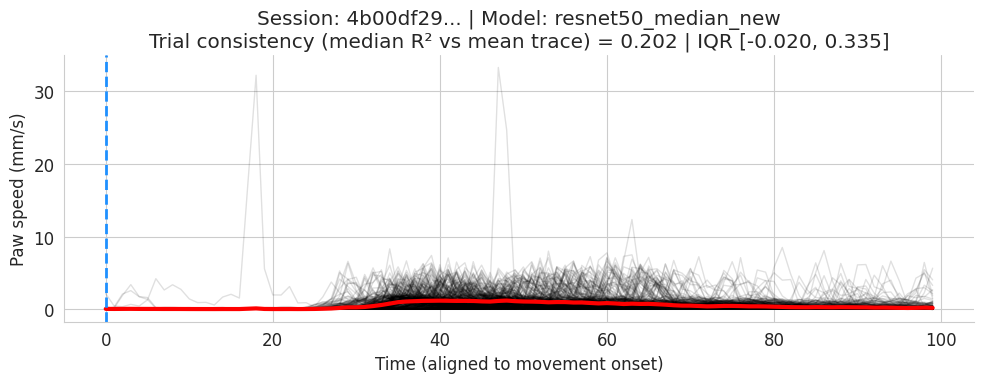

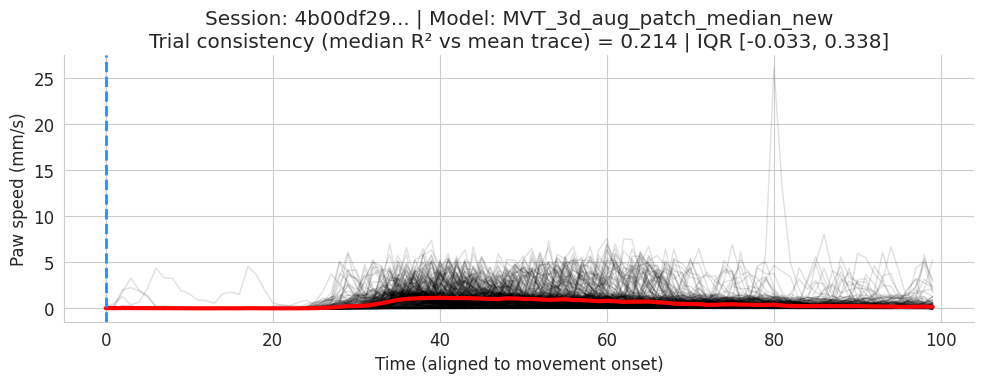

In [738]:
import numpy as np
import matplotlib.pyplot as plt

def trial_consistency_r2(y: np.ndarray):
    """
    Trial consistency = how well the mean trace across trials explains each trial.

    Args:
        y: array (n_trials, T)

    Returns:
        r2_trials: array (n_trials,)
        r2_median: float
        r2_iqr: (q25, q75)
        mean_trace: array (T,)
    """
    y = np.asarray(y)
    if y.ndim != 2:
        raise ValueError(f"y must be 2D (n_trials, T), got {y.shape}")

    n_trials, T = y.shape
    mean_trace = y.mean(axis=0)

    # SSE_i: error to mean trace
    sse = np.sum((y - mean_trace[None, :]) ** 2, axis=1)

    # SST_i: variance within each trial around its own mean over time
    y_trial_mean = y.mean(axis=1, keepdims=True)
    sst = np.sum((y - y_trial_mean) ** 2, axis=1)

    # Handle low-variance trials safely (sst ~ 0 => R2 undefined)
    eps = 1e-12
    valid = sst > eps
    r2_trials = np.full(n_trials, np.nan)
    r2_trials[valid] = 1.0 - (sse[valid] / sst[valid])

    r2_median = np.nanmedian(r2_trials)
    q25, q75 = np.nanpercentile(r2_trials, [25, 75])

    return r2_trials, r2_median, (q25, q75), mean_trace


def plot_trial_consistency(
    y: np.ndarray,
    time: np.ndarray = None,
    event_time: float = 0.0,
    title: str = "",
    ylabel: str = "Paw speed (mm/s)",
    alpha_trials: float = 0.12,
    lw_trials: float = 1.0,
    lw_mean: float = 3.0,
):
    """
    Panel E-style plot: gray single trials + red mean trace + trial consistency score.
    """
    y = np.asarray(y)
    n_trials, T = y.shape

    if time is None:
        time = np.arange(T)
    else:
        time = np.asarray(time)
        if time.shape[0] != T:
            raise ValueError(f"time length {time.shape[0]} != T {T}")

    r2_trials, r2_med, (q25, q75), mean_trace = trial_consistency_r2(y)

    fig, ax = plt.subplots(1, 1, figsize=(10, 4))

    # single trials
    for i in range(n_trials):
        ax.plot(time, y[i], color="black", alpha=alpha_trials, lw=lw_trials)

    # mean trace
    ax.plot(time, mean_trace, color="red", lw=lw_mean)

    # event line
    ax.axvline(event_time, color="dodgerblue", linestyle="--", lw=2)

    ax.set_title(
        (title + "\n" if title else "") +
        f"Trial consistency (median R² vs mean trace) = {r2_med:.3f} | IQR [{q25:.3f}, {q75:.3f}]"
    )
    ax.set_xlabel("Time (aligned to movement onset)")
    ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    return fig, ax

# Example usage:
# Load your data first (replace with actual data loading)
# Run trial consistency analysis for all models
for i, test_model in enumerate(pose_models):
    test_eid = eids[4]
    results_path = f"{base_path}/{test_eid}/{target}/{test_model}/linear/all/{test_eid}_cv.npy"
    
    try:
        data = np.load(results_path, allow_pickle=True).item()
        y = data['all_test_y']

        # Then run the analysis:
        fig, ax = plot_trial_consistency(
            y=y,
            title=f"Session: {test_eid[:8]}... | Model: {test_model}",
            ylabel="Paw speed (mm/s)"
        )
        plt.show()
    except FileNotFoundError:
        print(f"File not found: {results_path}")
    except Exception as e:
        print(f"Error loading {test_model}: {e}")

# Or just get the consistency metrics:
# r2_trials, r2_median, (q25, q75), mean_trace = trial_consistency_r2(y)
# print(f"Trial consistency R² median: {r2_median:.3f}, IQR: [{q25:.3f}, {q75:.3f}]")



In [680]:
# Replace with one of your actual EIDs and models from the plot
test_eid = eids[0] 
test_model = pose_models[0]
results_path = f"{base_path}/{test_eid}/{target}/{test_model}/linear/all/{test_eid}_cv.npy"

data = np.load(results_path, allow_pickle=True).item()
y = data['all_test_y']
pred = data['all_test_pred']

print(f"Checking file: {results_path}")
print(f"Shape Y: {y.shape}, Shape Pred: {pred.shape}")
print(f"Are they the exact same object in memory? {y is pred}")
print(f"Are all values identical? {np.array_equal(y, pred)}")
if not np.array_equal(y, pred):
    print(f"Max difference: {np.max(np.abs(y - pred))}")

Checking file: /media/lenny-aharon/T7/ibl-mouse/ibl-mouse_neural-activity/results/15b69921-d471-4ded-8814-2adad954bcd8/lightning-pose-pawL-3d-speed/resnet50_median_new/linear/all/15b69921-d471-4ded-8814-2adad954bcd8_cv.npy
Shape Y: (390, 100), Shape Pred: (390, 100)
Are they the exact same object in memory? False
Are all values identical? False
Max difference: 48.03333068938329


# From here this is for 1 session

In [659]:
results = load_session_results(base_path, eid, target, pose_models,model_method=model)


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15763234-d21e-491f-a01b-1238eb96d389
  Trials: 349
  R² (flattened): 0.158
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15763234-d21e-491f-a01b-1238eb96d389
  Trials: 349
  R² (flattened): 0.227
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords



--- resnet50_median_new Per-Bin R² Summary ---
  First bin (0ms):  -0.0188
  Middle bin (1s):  0.1532
  Last bin (2s):    0.0679
  Mean of all bins: 0.0862

--- MVT_3d_aug_patch_median_new Per-Bin R² Summary ---
  First bin (0ms):  -0.0036
  Middle bin (1s):  0.1822
  Last bin (2s):    0.0482
  Mean of all bins: 0.1177


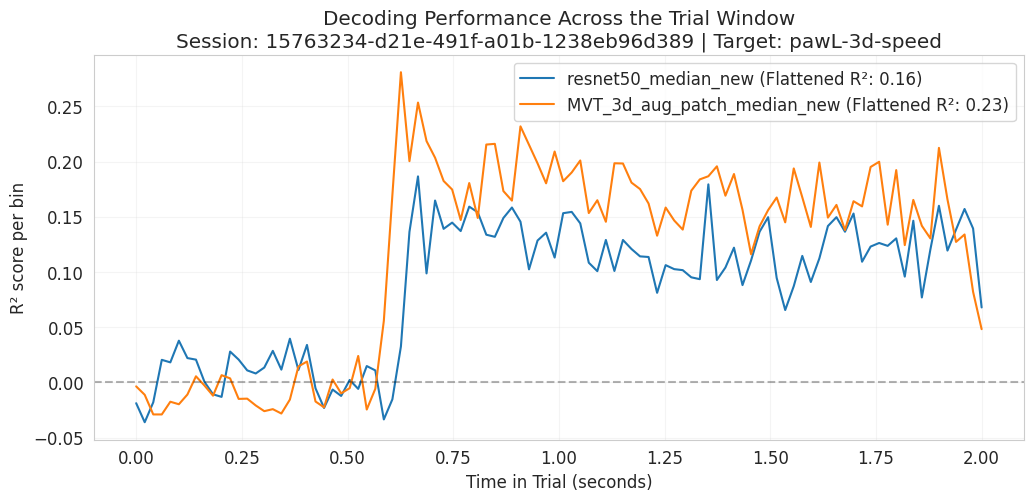

In [660]:
def analyze_per_bin_performance(results, pose_models):
    """
    Calculates and prints/plots R^2 for every time bin (0-100) for each model.
    """
    plt.figure(figsize=(12, 5))
    
    for model_name in pose_models:
        res = results[model_name]
        y_true = res['test_y']     # Shape: [n_trials, n_bins]
        y_pred = res['test_pred']   # Shape: [n_trials, n_bins]
        
        n_bins = y_true.shape[1]
        bin_r2s = []
        
        print(f"\n--- {model_name} Per-Bin R² Summary ---")
        for b in range(n_bins):
            # Calculate R2 for this specific bin across all trials
            r2 = r2_score(y_true[:, b], y_pred[:, b])
            bin_r2s.append(r2)
        
        # Print a few example bins
        print(f"  First bin (0ms):  {bin_r2s[0]:.4f}")
        print(f"  Middle bin (1s):  {bin_r2s[n_bins//2]:.4f}")
        print(f"  Last bin (2s):    {bin_r2s[-1]:.4f}")
        print(f"  Mean of all bins: {np.mean(bin_r2s):.4f}")
        
        # Plot the curve
        plt.plot(np.linspace(0, 2, n_bins), bin_r2s, label=f"{model_name} (Flattened R²: {res['r2']:.2f})")

    plt.axhline(0, color='black', linestyle='--', alpha=0.3)
    plt.xlabel("Time in Trial (seconds)")
    plt.ylabel("R² score per bin")
    target_without = target.replace("lightning-pose-", "")
    plt.title(f"Decoding Performance Across the Trial Window\nSession: {eid} | Target: {target_without}")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

# Run the analysis
analyze_per_bin_performance(results, pose_models)

In [661]:
results

{'resnet50_median_new': {'test_y': array([[ 0.08634448,  0.19071575,  0.09016812, ...,  0.11352185,
           0.0442964 ,  0.00868268],
         [ 1.62904774,  0.32985378,  1.15222909, ...,  0.90803537,
           1.14982923, -0.66829859],
         [ 0.12578654,  0.21151392,  0.13428233, ...,  0.01516295,
           0.01665746,  0.24983134],
         ...,
         [ 0.00677589,  0.00889583,  0.01184305, ...,  0.02084097,
           0.03208493, -0.01017779],
         [ 0.02622122,  0.05352055,  0.05870071, ...,  0.01783859,
           0.02913367,  0.05088002],
         [ 0.00249746,  0.00987703,  0.0113642 , ...,  0.01197422,
           0.01049752,  0.00580128]]),
  'test_pred': array([[ 0.34398634,  0.22875111,  0.14848144, ...,  0.12063471,
           0.48345906,  1.10038519],
         [ 0.24853443,  0.01346689,  0.12160779, ...,  0.55335345,
           0.42759719,  1.38698299],
         [ 0.28180731,  0.22439205,  0.19033904, ...,  0.12526219,
           0.32736283,  0.85055957],
  

In [662]:
# Define colors for each pose model
# Darker color for pose model (ground truth), lighter for decoded prediction
colors = {
    # 'MVT_patch_masking_median': {
    #     'pose': '#1f77b4',      # Dark blue
    #     'decoded': '#aec7e8'    # Light blue
    # },
    'MVT_3d_aug_patch_median': {
        'pose': '#1f77b4',      # Dark blue
        'decoded': '#aec7e8'    # Light blue
    },
    'resnet50_median': {
        'pose': '#d62728',      # Dark red
        'decoded': '#ff9896'    # Light red/pink
    },

    'MVT_3d_aug_patch_median_new': {
        'pose': '#1f77b4',      # Dark blue
        'decoded': '#aec7e8'    # Light blue
    },
    'resnet50_median_new': {
        'pose': '#d62728',      # Dark red
        'decoded': '#ff9896'    # Light red/pink
    },

    # 'MVT_3d_aug_patch_eks': {
    #     'pose': 'green',      
    #     'decoded': 'lightgreen'    
    # },

    'MVT_3d_aug_patch_eks_linear': {
        'pose': 'green',      
        'decoded': 'lightgreen'    
    },

    'MVT_3d_aug_patch_0': {
        'pose': '#1f77b4',      # Dark blue
        'decoded': '#aec7e8'    # Light blue
    },
    'resnet50_0': {
        'pose': '#d62728',      # Dark red
        'decoded': '#ff9896'    # Light red/pink
    }
}

(<Figure size 1400x1500 with 5 Axes>,
 array([<Axes: title={'center': 'pawL-3d-speed- Session: 15763234-d21e-491f-a01b-1238eb96d389 | Window: 0-800'}, ylabel='Speed (pix/s)'>,
        <Axes: ylabel='Avg Ensemble Var'>, <Axes: ylabel='X-3D'>,
        <Axes: ylabel='Y-3D'>,
        <Axes: xlabel='Time (seconds) & Video Frame Index', ylabel='Z-3D'>],
       dtype=object))

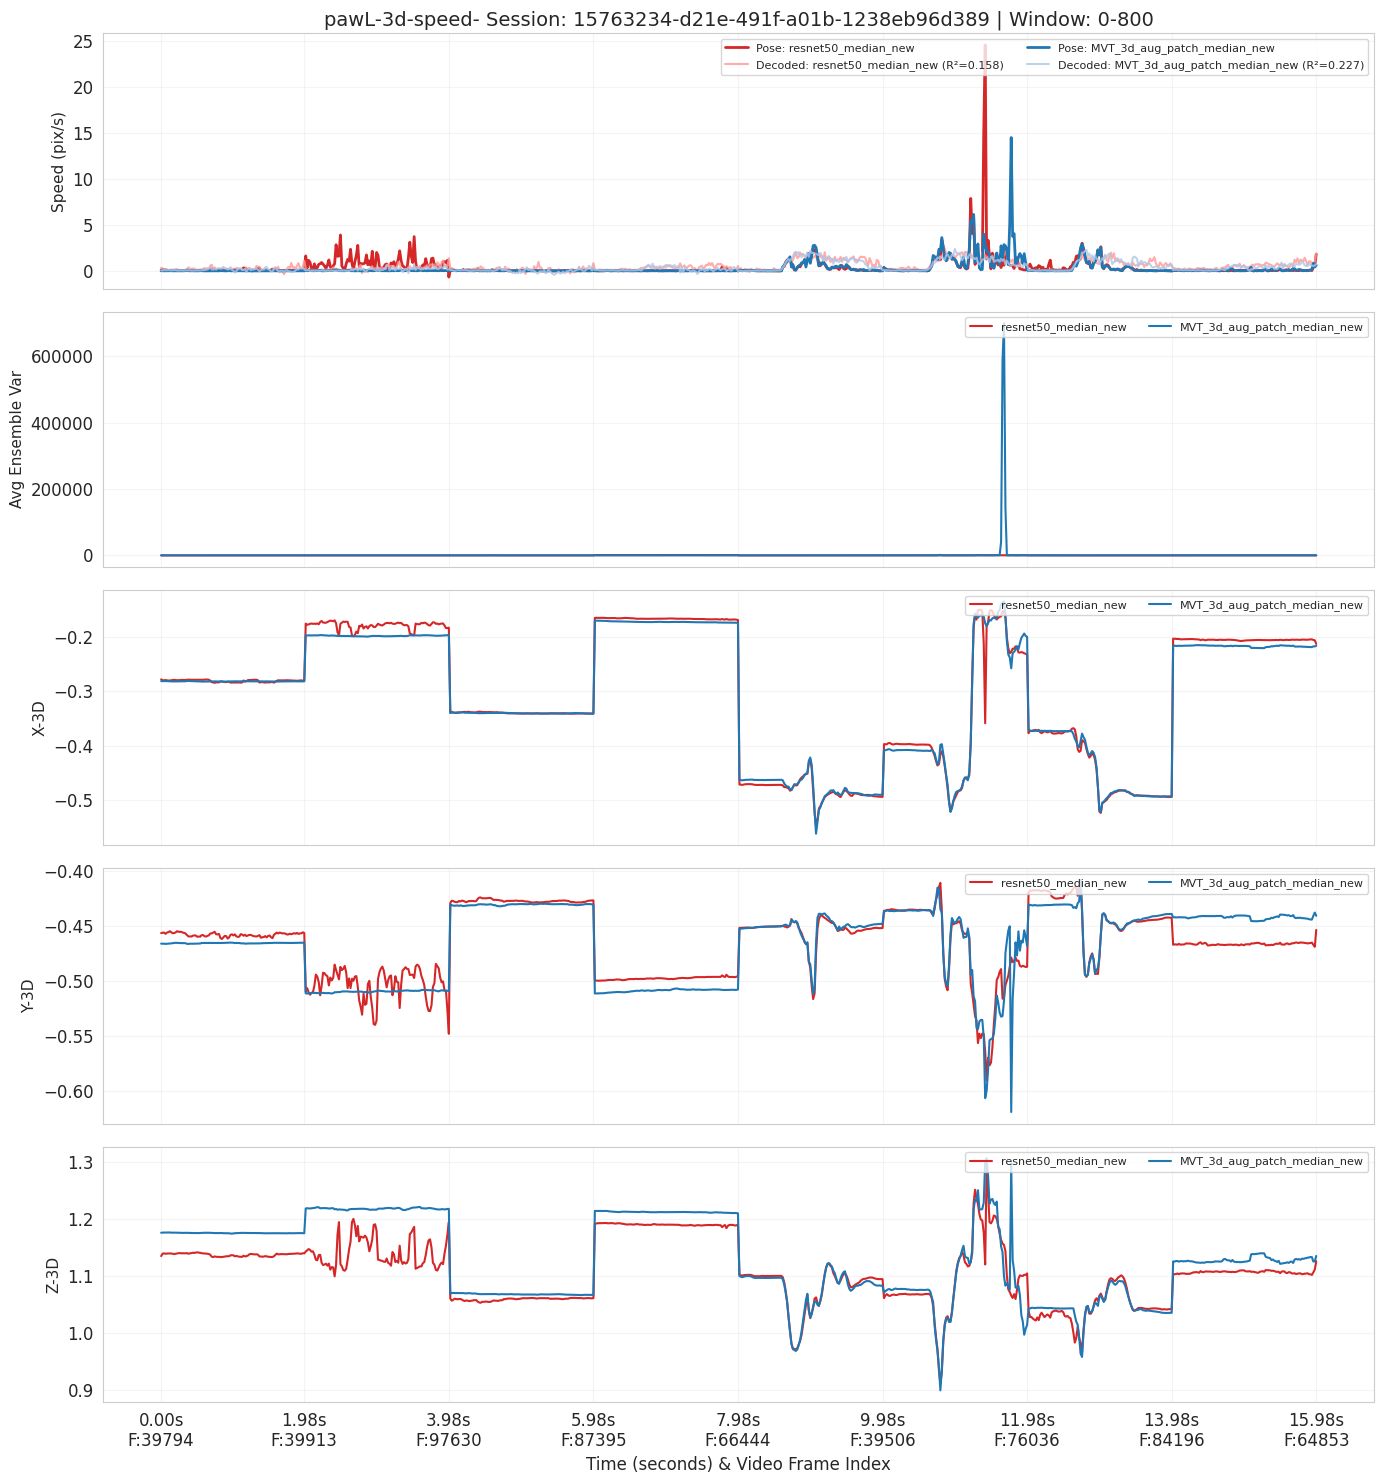

In [670]:
def plot_pose_results(results, pose_models, colors, eid, 
                      plots_to_show=None, 
                      start_time=0, 
                      end_time=800, 
                      sampling_rate=0.02,
                      target=target):
    
    # --- 1. LOAD MAPPING METADATA ---
    common_data_path = Path("/media/lenny-aharon/T7/ibl-mouse/ibl-mouse_neural-activity/ibl_aligned") / eid
    alignment_info = np.load(common_data_path / "alignment_info.npy", allow_pickle=True).item()
    trial_intervals = alignment_info["trial_intervals"] 
    timestamp_file = Path("/media/lenny-aharon/T7/ibl-mouse/timestamps") / f"_ibl_leftCamera.times.{eid}.npy"
    frame_times = np.load(timestamp_file)
    
    orig_trial_ids = results[pose_models[0]]['test_original_trial_ids']
    trial_len_bins = 100 

    # --- 2. UPDATED PLOT CONFIG ---
    # We map the keys we added in the loader to user-friendly labels
    plot_config = {
        'speed': {'label': 'Speed (pix/s)', 'data_key': 'y_flattened'},
        'avg_var': {'label': 'Avg Ensemble Var', 'data_key': 'avg_ens_var_flattened'}, # <--- USE THIS
        'x_3d': {'label': 'X-3D', 'data_key': 'x_3d_flattened'},
        'y_3d': {'label': 'Y-3D', 'data_key': 'y_3d_flattened'},
        'z_3d': {'label': 'Z-3D', 'data_key': 'z_3d_flattened'}
    }

    if plots_to_show is None:
        plots_to_show = list(plot_config.keys())

    num_plots = len(plots_to_show)
    fig, axes = plt.subplots(num_plots, 1, figsize=(14, 3 * num_plots), sharex=True)
    if num_plots == 1: axes = [axes]

    for i, plot_key in enumerate(plots_to_show):
        ax = axes[i]
        config = plot_config.get(plot_key, {'label': plot_key, 'data_key': f"{plot_key}_flattened"})
        
        for pose_model in pose_models:
            res = results[pose_model]
            color_pose = colors[pose_model]['pose']
            
            if plot_key == 'speed':
                ax.plot(res['y_flattened'][start_time:end_time], color=color_pose, linewidth=2, label=f"Pose: {pose_model}")
                ax.plot(res['pred_flattened'][start_time:end_time], color=colors[pose_model]['decoded'], linewidth=1.5, 
                        label=f"Decoded: {pose_model} (R²={res['r2']:.3f})", alpha=0.8)
            else:
                # General plotting for all coordinate and variance keys
                data = res.get(config['data_key'])
                if data is not None:
                    ax.plot(data[start_time:end_time], color=color_pose, label=f"{pose_model}")

        ax.set_ylabel(config['label'], fontsize=11)
        ax.legend(fontsize=8, loc='upper right', ncol=2)
        ax.grid(True, alpha=0.2)

    # --- 3. DYNAMIC X-AXIS WITH VIDEO FRAMES ---
    duration_frames = end_time - start_time
    tick_indices = np.linspace(0, duration_frames - 1, 9, dtype=int)
    time_labels, frame_labels = [], []

    for idx in tick_indices:
        global_idx = start_time + idx
        time_labels.append(f"{(global_idx * sampling_rate):.2f}s")
        
        # trial_idx_in_test = global_idx // trial_len_bins
        # bin_within_trial = global_idx % trial_len_bins
        
        # if trial_idx_in_test < len(orig_trial_ids):
        #     orig_id = orig_trial_ids[trial_idx_in_test]
        #     bin_time = trial_intervals[orig_id][0] + (bin_within_trial * sampling_rate)
        #     video_frame = np.searchsorted(frame_times, bin_time)
        #     frame_labels.append(f"F:{video_frame}")
        # else:
        #     frame_labels.append("")

         # --- Inside the dynamic X-axis loop ---
        trial_idx_in_test = global_idx // trial_len_bins
        bin_within_trial = global_idx % trial_len_bins
        
        # ADD THIS CHECK: Ensure orig_trial_ids is not None
        if orig_trial_ids is not None and trial_idx_in_test < len(orig_trial_ids):
            orig_id = orig_trial_ids[trial_idx_in_test]
            bin_time = trial_intervals[orig_id][0] + (bin_within_trial * sampling_rate)
            video_frame = np.searchsorted(frame_times, bin_time)
            frame_labels.append(f"F:{video_frame}")
        else:
            # Fallback if mapping is missing
            frame_labels.append("")

    axes[-1].set_xticks(tick_indices)
    axes[-1].set_xticklabels([f"{t}\n{f}" for t, f in zip(time_labels, frame_labels)])
    axes[-1].set_xlabel("Time (seconds) & Video Frame Index", fontsize=12)
    
    lightning_pose_without = target.replace("lightning-pose-", "")
    axes[0].set_title(f"{lightning_pose_without}- Session: {eid} | Window: {start_time}-{end_time}", fontsize=14)
    plt.tight_layout()
    return fig, axes

# --- Example of showing the new average variance plots ---
plots_to_show = ['speed', 'avg_var','x_3d', 'y_3d', 'z_3d']
plot_pose_results(results, pose_models, colors, eid, plots_to_show, start_time=0, end_time=800)

(<Figure size 1400x1500 with 5 Axes>,
 array([<Axes: title={'center': 'pawL-3d-speed- Session: 15763234-d21e-491f-a01b-1238eb96d389 | Window: 100-200'}, ylabel='Speed (pix/s)'>,
        <Axes: ylabel='Avg Ensemble Var'>, <Axes: ylabel='X-3D'>,
        <Axes: ylabel='Y-3D'>,
        <Axes: xlabel='Time (seconds) & Video Frame Index', ylabel='Z-3D'>],
       dtype=object))

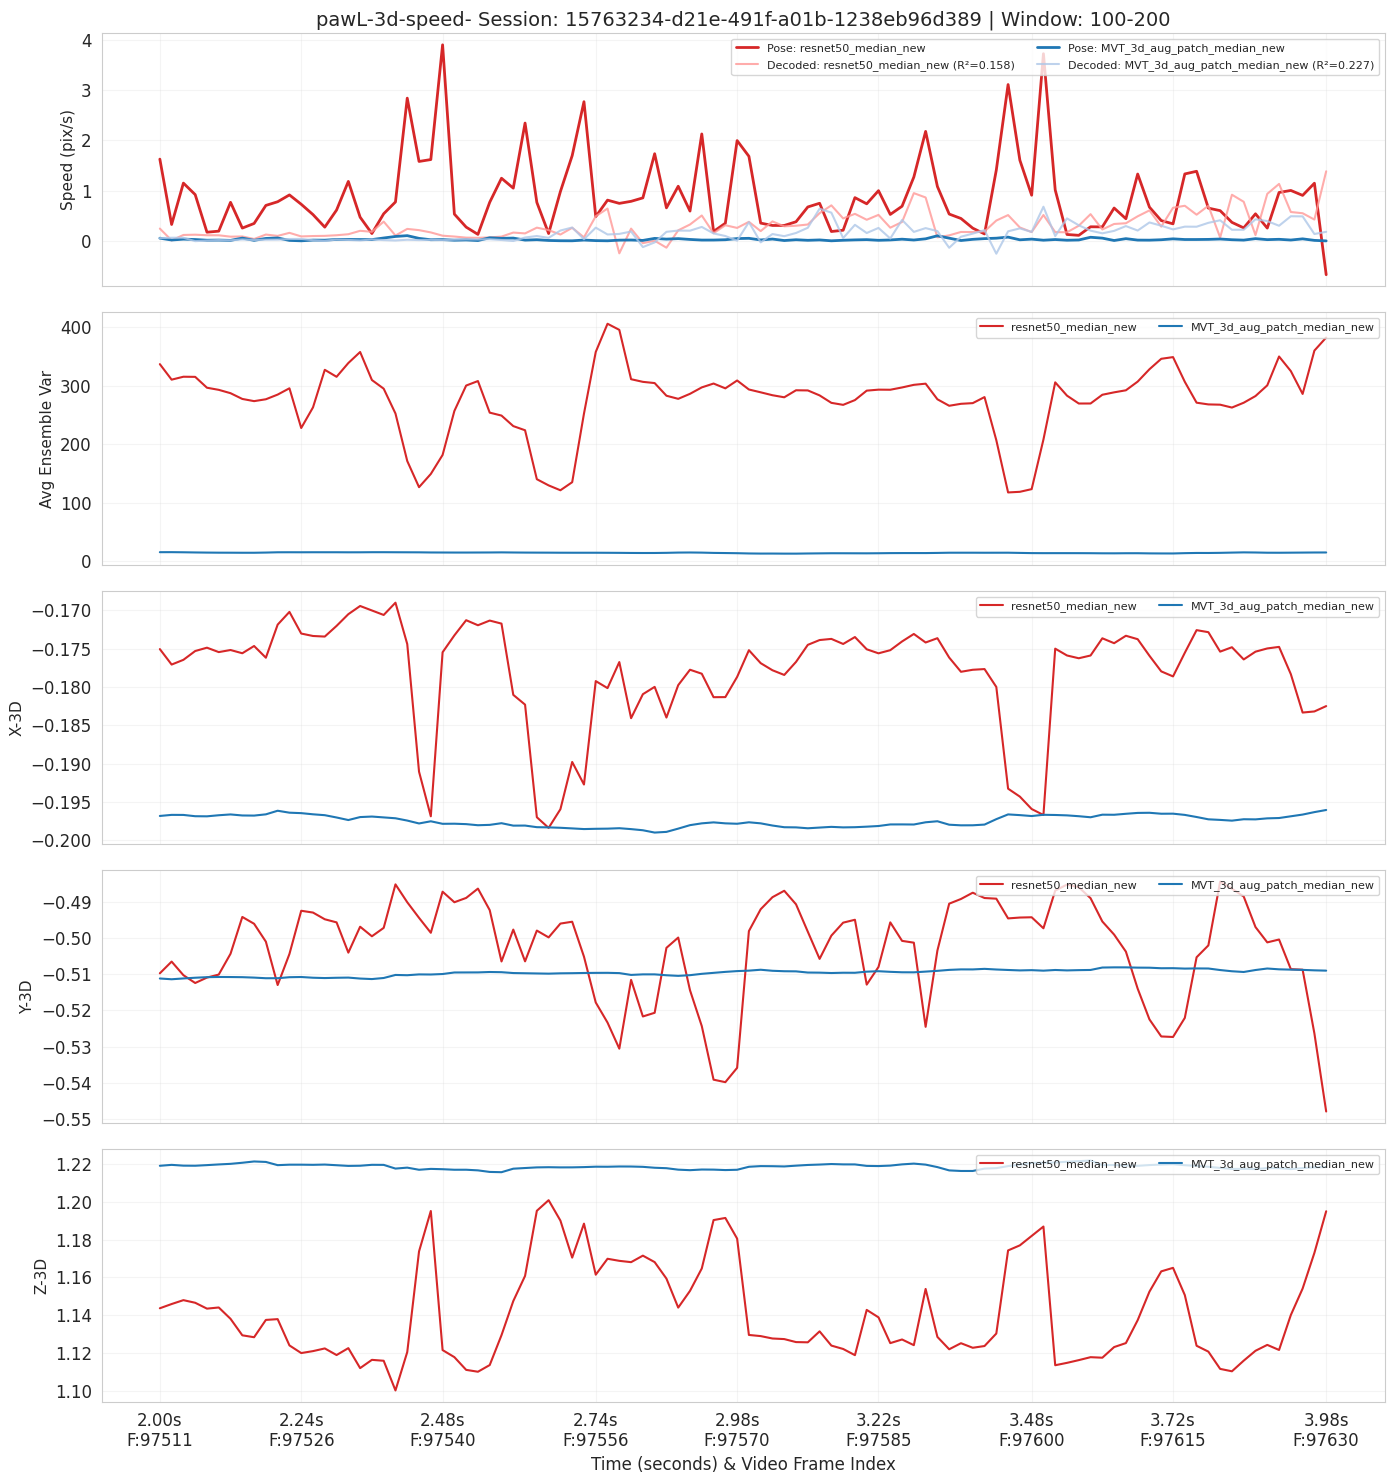

In [672]:
plots_to_show = ['speed','avg_var','x_3d', 'y_3d', 'z_3d']

plot_pose_results(results, pose_models, colors, eid, plots_to_show, start_time=100, end_time=200)

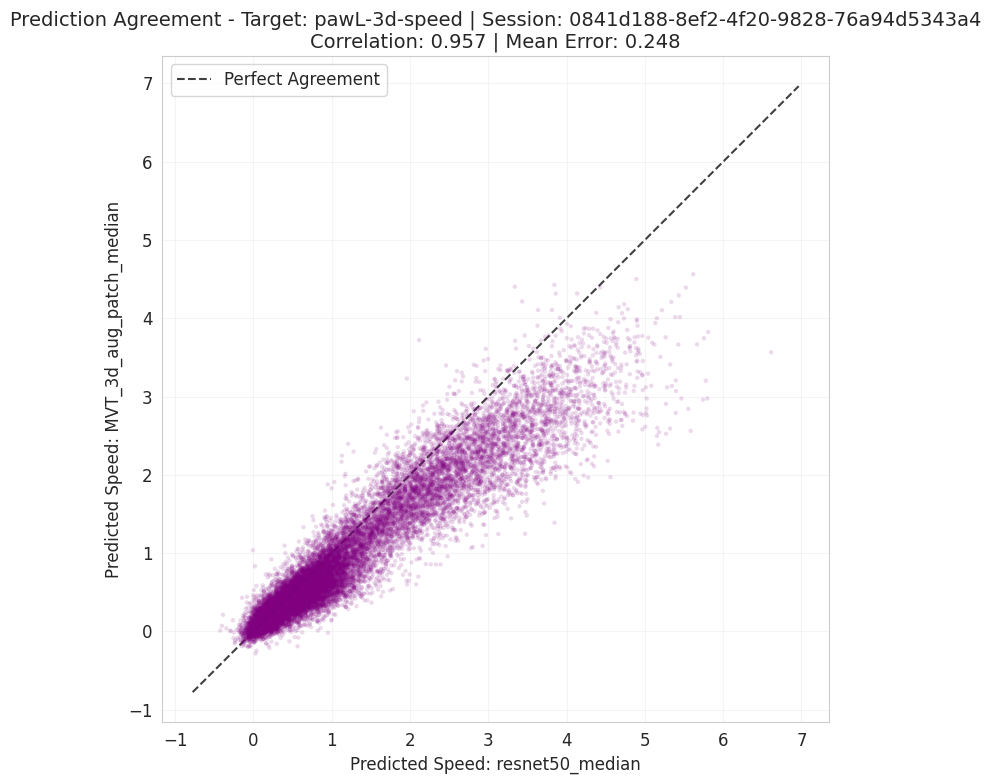

In [49]:
def plot_prediction_agreement(results, pose_models,target=target):
    """
    Creates a scatter plot comparing the neural predictions of two models.
    """
    if len(pose_models) < 2:
        print("Need at least two models to compare.")
        return

    # Get the flattened predictions for the first two models
    m1, m2 = pose_models[0], pose_models[1]
    pred1 = results[m1]['pred_flattened']
    pred2 = results[m2]['pred_flattened']
    
    # Ensure they are the same length (they should be for the same session)
    min_len = min(len(pred1), len(pred2))
    pred1, pred2 = pred1[:min_len], pred2[:min_len]

    # Calculate disagreement metrics
    correlation = np.corrcoef(pred1, pred2)[0, 1]
    mean_diff = np.mean(np.abs(pred1 - pred2))
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Scatter plot with high transparency to see density
    ax.scatter(pred1, pred2, alpha=0.15, s=10, color='purple', edgecolors='none')
    
    # Add identity line (y=x) - where they would perfectly agree
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),
        np.max([ax.get_xlim(), ax.get_ylim()]),
    ]
    ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='Perfect Agreement')
    
    # Formatting
    ax.set_xlabel(f"Predicted Speed: {m1}", fontsize=12)
    ax.set_ylabel(f"Predicted Speed: {m2}", fontsize=12)
    target_without = target.replace("lightning-pose-", "")
    ax.set_title(f"Prediction Agreement - Target: {target_without} | Session: {eid}\nCorrelation: {correlation:.3f} | Mean Error: {mean_diff:.3f}", fontsize=14)
    
    ax.grid(True, alpha=0.2)
    ax.set_aspect('equal')
    ax.legend()
    
    plt.tight_layout()
    plt.show()  # Explicitly show the plot to prevent duplicate display
    return fig

# Call the function
fig = plot_prediction_agreement(results, pose_models)

In [50]:
from sklearn.metrics import mean_squared_error, r2_score

def analyze_disagreement_performance(results, pose_models, percentile=90, target=target):
    """
    Identifies frames where predictions differ most and evaluates 
    decoding performance on those specific frames.
    """
    m1, m2 = pose_models[0], pose_models[1]
    
    # 1. Get predictions and ground truths
    p1, p2 = results[m1]['pred_flattened'], results[m2]['pred_flattened']
    y1, y2 = results[m1]['y_flattened'], results[m2]['y_flattened']
    
    # 2. Compute absolute disagreement between the two NEURAL predictions
    disagreement = np.abs(p1 - p2)
    
    # 3. Define "High Disagreement" frames (e.g., the top 10% most different)
    threshold = np.percentile(disagreement, percentile)
    mask = disagreement >= threshold
    
    num_frames = np.sum(mask)
    print(f"Analyzing {num_frames} frames of high disagreement (Top {100-percentile}%)...")
    target_without = target.replace("lightning-pose-", "")
    print(f"Target: {target_without} | Session: {eid}")
    print(f"Disagreement threshold: {threshold:.3f} pix/s")
    
    # 4. Compute metrics ONLY on these frames
    metrics = {}
    for m in [m1, m2]:
        pred_subset = results[m]['pred_flattened'][mask]
        truth_subset = results[m]['y_flattened'][mask]
        
        mse = mean_squared_error(truth_subset, pred_subset)
        r2 = r2_score(truth_subset, pred_subset)
        corr = np.corrcoef(truth_subset, pred_subset)[0, 1]
        
        metrics[m] = {'mse': mse, 'r2': r2, 'corr': corr}
    
    # 5. Print Comparison
    print(f"\n{'Model':<25} | {'MSE (Loss)':<12} | {'R²':<10} | {'Correlation'}")
    print("-" * 65)
    for m in [m1, m2]:
        met = metrics[m]
        print(f"{m:<25} | {met['mse']:<12.4f} | {met['r2']:<10.3f} | {met['corr']:.3f}")
        
    return mask, metrics

# Run the analysis
disagreement_mask, disagreement_metrics = analyze_disagreement_performance(results, pose_models)

Analyzing 2340 frames of high disagreement (Top 10%)...
Target: pawL-3d-speed | Session: 0841d188-8ef2-4f20-9828-76a94d5343a4
Disagreement threshold: 0.653 pix/s

Model                     | MSE (Loss)   | R²         | Correlation
-----------------------------------------------------------------
resnet50_median           | 19.2613      | 0.080      | 0.294
MVT_3d_aug_patch_median   | 8.8259       | 0.095      | 0.318


# This code evaluates each model against its own internal "difficulty" (ensemble variance), which means that the 10th percentile" for Model A might have included different frames than the "10th percentile" for Model B.

 the bin r^2 for model resnet50_median is -1.5152503802304063
 the bin r^2 for model resnet50_median is -0.6549582301361283
 the bin r^2 for model resnet50_median is -0.29134927772547203
 the bin r^2 for model resnet50_median is -0.10456460637366138
 the bin r^2 for model resnet50_median is 0.027997434444537617
 the bin r^2 for model resnet50_median is 0.06519817531024918
 the bin r^2 for model resnet50_median is 0.16148757603750408
 the bin r^2 for model resnet50_median is 0.12005988647790888
 the bin r^2 for model resnet50_median is 0.16891674214993846
 the bin r^2 for model resnet50_median is 0.03729249525917466
 the bin r^2 for model MVT_3d_aug_patch_median is -0.7671370650131175
 the bin r^2 for model MVT_3d_aug_patch_median is -0.2128452342183278
 the bin r^2 for model MVT_3d_aug_patch_median is -0.05372990864593441
 the bin r^2 for model MVT_3d_aug_patch_median is 0.16353573109254615
 the bin r^2 for model MVT_3d_aug_patch_median is 0.23153663669584812
 the bin r^2 for model MVT

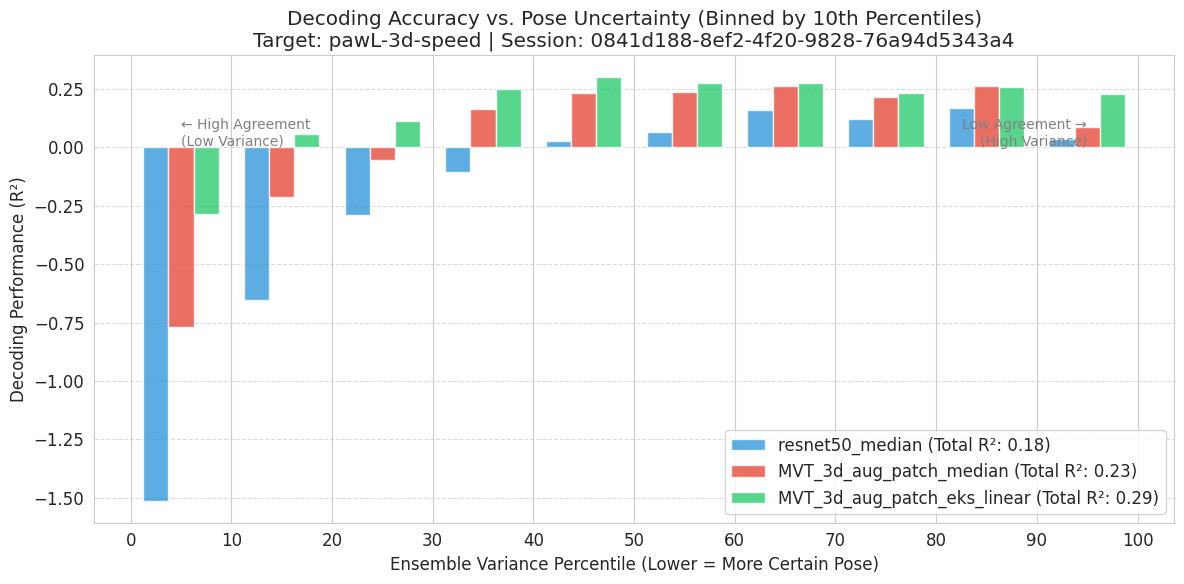

In [51]:

def plot_performance_by_variance_percentiles(results, pose_models, n_bins=10):
    """
    Bins the data by ensemble variance percentiles and computes R^2 for each bin.
    """
    plt.figure(figsize=(12, 6))
    
    # Define the percentile edges (0, 10, 20, ..., 100)
    percentiles = np.linspace(0, 100, n_bins + 1)
    bin_centers = (percentiles[:-1] + percentiles[1:]) / 2
    
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f']
    
    for i, model_name in enumerate(pose_models):
        res = results[model_name]
        
        # Get flattened ground truth, predictions, and variance
        y_true = res['y_flattened']
        y_pred = res['pred_flattened']
        
        # Use the unified average variance we calculated during loading
        if 'avg_ens_var_flattened' not in res:
            print(f"Skipping {model_name}: No ensemble variance found.")
            continue
            
        var = res['avg_ens_var_flattened']
        
        # Calculate percentile thresholds for this model's variance
        thresholds = np.percentile(var, percentiles)
        
        bin_r2s = []
        bin_counts = []
        
        for j in range(n_bins):
            # Create mask for frames in this variance percentile bin
            lower = thresholds[j]
            upper = thresholds[j+1]
            
            # Handle the last bin inclusive edge
            if j == n_bins - 1:
                mask = (var >= lower) & (var <= upper)
            else:
                mask = (var >= lower) & (var < upper)
            
            if np.sum(mask) > 10:  # Need enough points for a stable R2
                r2 = r2_score(y_true[mask], y_pred[mask])
                bin_r2s.append(r2)
            else:
                bin_r2s.append(0)
            bin_counts.append(np.sum(mask))
            print(f" the bin r^2 for model {model_name} is {r2}")

            
        # Plotting the bars
        # Offsetting bars slightly so they don't overlap if comparing multiple models
        width = 10 / (len(pose_models) + 1)
        offset = (i - len(pose_models)/2 + 0.5) * width
        
        plt.bar(bin_centers + offset, bin_r2s, width=width, 
                label=f"{model_name} (Total R²: {res['r2']:.2f})", 
                color=colors[i % len(colors)], alpha=0.8)

    plt.xlabel('Ensemble Variance Percentile (Lower = More Certain Pose)')
    plt.ylabel('Decoding Performance (R²)')
    target_without = target.replace("lightning-pose-", "")
    plt.title(f'Decoding Accuracy vs. Pose Uncertainty (Binned by 10th Percentiles)\nTarget: {target_without} | Session: {eid}')
    plt.xticks(percentiles)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add info about what low/high percentiles mean
    plt.text(5, plt.ylim()[1]*0.02, "← High Agreement\n(Low Variance)", ha='left', fontsize=10, color='gray')
    plt.text(95, plt.ylim()[1]*0.02, "Low Agreement →\n(High Variance)", ha='right', fontsize=10, color='gray')

    plt.tight_layout()
    plt.show()

# Run the analysis
plot_performance_by_variance_percentiles(results, pose_models)

# To compare them fairly on the exact same frames, we should use a shared uncertainty scale. we do this by averging the ensemble variances of both pose models to define a single "global difficulty" for every frame. Same frames for all of the precentiles.

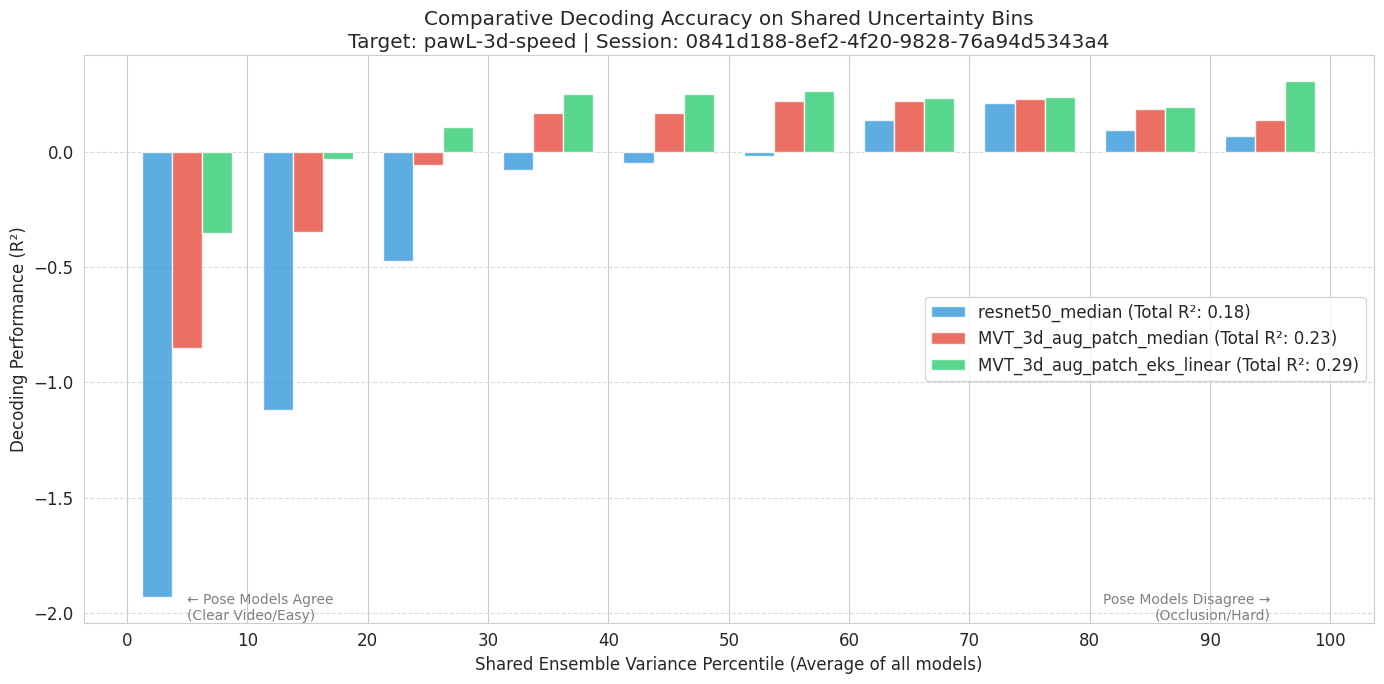

In [52]:
def plot_performance_by_shared_variance(results, pose_models, n_bins=10):
    """
    Computes a shared uncertainty scale by averaging variances from all models,
    then evaluates each model on the exact same frames per bin.
    """
    # 1. Ensure models are aligned and compute shared variance
    # (Assuming all models have the same number of frames from the same CV splits)
    all_vars = []
    for m in pose_models:
        if 'avg_ens_var_flattened' in results[m]:
            all_vars.append(results[m]['avg_ens_var_flattened'])
    
    if not all_vars:
        print("Error: No ensemble variance found in results.")
        return

    # Compute the average variance across all pose models for every frame
    shared_var = np.mean(all_vars, axis=0)
    # shared_var = np.max(all_vars, axis=0)
    
    # 2. Define shared percentile thresholds based on this global scale
    percentiles = np.linspace(0, 100, n_bins + 1)
    thresholds = np.percentile(shared_var, percentiles)
    bin_centers = (percentiles[:-1] + percentiles[1:]) / 2
    
    # 3. Plotting
    plt.figure(figsize=(14, 7))
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f']
    width = 10 / (len(pose_models) + 1)
    
    for i, model_name in enumerate(pose_models):
        res = results[model_name]
        y_true = res['y_flattened']
        y_pred = res['pred_flattened']
        
        bin_r2s = []
        
        for j in range(n_bins):
            # Use the SHARED_VAR to create the mask (same frames for all models)
            lower, upper = thresholds[j], thresholds[j+1]
            if j == n_bins - 1:
                mask = (shared_var >= lower) & (shared_var <= upper)
            else:
                mask = (shared_var >= lower) & (shared_var < upper)
            
            if np.sum(mask) > 10:
                r2 = r2_score(y_true[mask], y_pred[mask])
                bin_r2s.append(r2)
            else:
                bin_r2s.append(0)
        
        offset = (i - len(pose_models)/2 + 0.5) * width
        plt.bar(bin_centers + offset, bin_r2s, width=width, 
                label=f"{model_name} (Total R²: {res['r2']:.2f})", 
                color=colors[i % len(colors)], alpha=0.8)

    plt.xlabel('Shared Ensemble Variance Percentile (Average of all models)')
    plt.ylabel('Decoding Performance (R²)')
    target_without = target.replace("lightning-pose-", "")
    plt.title(f'Comparative Decoding Accuracy on Shared Uncertainty Bins\nTarget: {target_without} | Session: {eid}')
    plt.xticks(percentiles)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.text(5, plt.ylim()[0], "← Pose Models Agree\n(Clear Video/Easy)", ha='left', va='bottom', fontsize=10, color='gray')
    plt.text(95, plt.ylim()[0], "Pose Models Disagree →\n(Occlusion/Hard)", ha='right', va='bottom', fontsize=10, color='gray')

    plt.tight_layout()
    plt.show()

# Run the updated analysis
plot_performance_by_shared_variance(results, pose_models)

In [89]:
import pandas as pd

# 1. Load Alignment and Timestamps
common_data_path = Path("/media/lenny-aharon/T7/ibl-mouse/ibl-mouse_neural-activity/ibl_aligned") / eid
alignment_info = np.load(common_data_path / "alignment_info.npy", allow_pickle=True).item()
trial_intervals = alignment_info["trial_intervals"] 

timestamp_file = Path("/media/lenny-aharon/T7/ibl-mouse/timestamps") / f"_ibl_leftCamera.times.{eid}.npy"
frame_times = np.load(timestamp_file)

# 2. Get the trials in the order they appear in your plot
orig_trial_ids = results[pose_models[0]]['test_original_trial_ids']

mapping_list = []

for i, orig_id in enumerate(orig_trial_ids):
    # Get the start and end time for this 2-second trial
    t_start, t_end = trial_intervals[orig_id]
    
    # Find the exact indices in the 100,000 frame video
    raw_frame_start = np.searchsorted(frame_times, t_start, side="left")
    raw_frame_end = np.searchsorted(frame_times, t_end, side="right")
    
    mapping_list.append({
        'Plot_Trial_Index': i,
        'Plot_Time_Range': f"{i*2}-{(i+1)*2}s",
        'Session_Trial_ID': orig_id,
        'Video_Frame_Start': raw_frame_start,
        'Video_Frame_End': raw_frame_end,
        'Total_Video_Frames': raw_frame_end - raw_frame_start
    })

# Display as a table
mapping_df = pd.DataFrame(mapping_list)
print(mapping_df.head(10)) # Show first 10 trials

   Plot_Trial_Index Plot_Time_Range  Session_Trial_ID  Video_Frame_Start  \
0                 0            0-2s                 9               3398   
1                 1            2-4s                46              11969   
2                 2            4-6s                36               9966   
3                 3            6-8s               341              80932   
4                 4           8-10s               299              70857   
5                 5          10-12s               412              96972   
6                 6          12-14s                60              15437   
7                 7          14-16s               295              69962   
8                 8          16-18s               269              64183   
9                 9          18-20s               125              30399   

   Video_Frame_End  Total_Video_Frames  
0             3520                 122  
1            12091                 122  
2            10088                 122  

# This is Good until here